---
# COSC2673 (Computational) Machine Learning - Assignment 2 
## Machine Learning Classification and Model Comparison By Alissa Nguyen (s4085541)
---

## Introduction 

This assignment focuses on developing and comparing models for Predicting Wildfire Intensity Levels. In this assignment, the model must predict one of four fire intensity classes (Low, Moderate, High, Extreme).

#### Dataset overview
The dataset contains wildfire detection records with information such as location, date and time of detection, satellite observations, weather conditions, and environmental features. The prediction target is `fire_intensity`, which describes the intensity level of a detected wildfire event.

#### Prediction target
This is a relevant real world problem, since wildfire intensity predictions can affect response decisions. If a model underestimates fire intensity, emergency response may be underprepared. If it overestimates intensity, limited resources may be sent unnecessarily. Because of this, I will not only compare models based on accuracy, but also consider F1-score, class-level performance, model stability, and how explainable each model is.

The three required models developed in this notebook are:

1. Decision Tree  
2. Support Vector Machine (SVM)  
3. Neural Network  

The notebook follows the machine learning workflow expected for this assignment: loading and inspecting the data, conducting exploratory data analysis, preprocessing the features, splitting the labelled data into training and validation sets, developing and tuning the three models, comparing their behaviour, selecting a final model, and generating predictions for the test dataset.

#### Instructions - How to Run This Notebook
Before running the model, ensure that 
1. A Python environment is installed (Anaconda or standard Python with Jupyter Notebook) 
2. Place the following files in the same folder as the notebook: `wildfire_cls_train_full.csv` and `wildfire_cls_test_features.csv`
3. Make sure you have the following libraries installed: pandas, numpy, matplotlib, scikit-learn 

To run this notebook
4. Start jupyter notebook/lab
5. Run the cells from top to bottom order
6. The notebook will load the data, inspect and analyse the dataset, preprocess the features, train and evaluate three machine learning models, compare their performance, and generate the final prediction CSV.
7. The final prediction file will be saved as `s4085541_predictions.csv` (this file must contain one column only `fire_intensity` and predictions must remain in the same order as the rows in the provided test dataset)    

## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split


from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer


from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier


from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


RANDOM_STATE = 42


pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


importing the libraries needed for data handling, visualisation, preprocessing, model training, model evaluation, and final prediction generation.

## 2. Load data 
The assignment provides two datasets: a labelled training dataset and an unlabelled test dataset. The training data is used for exploratory analysis, preprocessing, model training, validation, and model selection. The test data is kept separate and is only used at the end to generate the final prediction CSV.

Keeping the test data separate is important because it prevents the model development process from being influenced by the data that will be used for final prediction.

### 2.1 Load training data
the models will learn to predict the target column `fire_intensity` . 

In [2]:
train_path = "wildfire_cls_train_full.csv"
train_df = pd.read_csv(train_path)

print("Training data loaded successfully.")
print("Training data shape:", train_df.shape)

Training data loaded successfully.
Training data shape: (4340, 20)


### 2.2 Load test data  
The test dataset contains the same input features as the training data, but it does not include `fire_intensity`. This is the dataset used at the end of the notebook to generate the final predictions for submission. 

In [3]:
test_path = "wildfire_cls_test_features.csv"
test_df = pd.read_csv(test_path)

print("Test data loaded successfully.")
print("Test data shape:", test_df.shape)

Test data loaded successfully.
Test data shape: (1085, 19)


### 2.3 Check train/test columns
Before doing any modelling, I need to confirm that the training and test datasets have matching feature columns. The training dataset should have one extra column because it includes the target variable `fire_intensity`.

In [4]:
target_col = "fire_intensity"

train_feature_cols = train_df.drop(columns=[target_col]).columns

test_feature_cols = test_df.columns

columns_match = list(train_feature_cols) == list(test_feature_cols)

print("Do the training and test feature columns match?", columns_match)

print("\nTraining feature columns:")
print(list(train_feature_cols))

print("\nTest feature columns:")
print(list(test_feature_cols))

Do the training and test feature columns match? True

Training feature columns:
['latitude', 'longitude', 'acq_date', 'acq_time', 'year', 'month', 'season', 'daynight', 'region', 'country', 'fire_type', 'satellite', 'instrument', 'brightness_k', 'confidence', 'temp_max_c', 'wind_max_kmh', 'precip_mm', 'humidity_pct']

Test feature columns:
['latitude', 'longitude', 'acq_date', 'acq_time', 'year', 'month', 'season', 'daynight', 'region', 'country', 'fire_type', 'satellite', 'instrument', 'brightness_k', 'confidence', 'temp_max_c', 'wind_max_kmh', 'precip_mm', 'humidity_pct']


The training and test feature columns match once the target column is removed from the training data. This means the same preprocessing steps can be applied consistently to both datasets later in the notebook.

## 3. Data inspection
This section inspects the basic structure of the dataset before deeper analysis. I check the dataset size, data types, example rows, target variable, and missing values. This helps identify what needs to be cleaned or transformed before the models are trained. 
#### 3.5 Missing value summary


### 3.1 Dataset shape 
The dataset shape shows how many rows and columns are available in the training and test datasets. This gives a quick overview of the amount of data available for model development and final prediction. 

In [5]:
print("Training dataset:")
print(f"Rows: {train_df.shape[0]}")
print(f"Columns: {train_df.shape[1]}")

print("\nTest dataset:")
print(f"Rows: {test_df.shape[0]}")
print(f"Columns: {test_df.shape[1]}")

Training dataset:
Rows: 4340
Columns: 20

Test dataset:
Rows: 1085
Columns: 19


The training dataset contains the labelled examples used for model development, while the test dataset contains the unlabelled examples for final prediction. The test dataset has one fewer column because it does not include the target variable.

### 3.2 Data types

In [6]:
#show the data type of each training column
train_df.dtypes

latitude          float64
longitude         float64
acq_date           object
acq_time            int64
year                int64
month             float64
season             object
daynight           object
region             object
country            object
fire_type          object
satellite          object
instrument         object
brightness_k      float64
confidence         object
temp_max_c        float64
wind_max_kmh      float64
precip_mm         float64
humidity_pct      float64
fire_intensity     object
dtype: object

In [7]:
#more detailed dataset information
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   latitude        4340 non-null   float64
 1   longitude       4340 non-null   float64
 2   acq_date        4340 non-null   object 
 3   acq_time        4340 non-null   int64  
 4   year            4340 non-null   int64  
 5   month           3924 non-null   float64
 6   season          4340 non-null   object 
 7   daynight        4340 non-null   object 
 8   region          4340 non-null   object 
 9   country         4340 non-null   object 
 10  fire_type       4340 non-null   object 
 11  satellite       4340 non-null   object 
 12  instrument      4340 non-null   object 
 13  brightness_k    4013 non-null   float64
 14  confidence      4340 non-null   object 
 15  temp_max_c      4340 non-null   float64
 16  wind_max_kmh    4133 non-null   float64
 17  precip_mm       4340 non-null   f

The dataset contains a mixture of numerical, categorical, date, and time-related features. This means the data cannot be passed directly into all models without preprocessing.

The numerical features include values such as latitude, longitude, acquisition time, brightness temperature, maximum temperature, wind speed, precipitation, and humidity. The categorical features include variables such as season, day/night, region, country, fire type, satellite, instrument, and confidence level.

The `acq_date` column is currently stored as an object. Since the dataset already includes `year` and `month`, I will inspect this feature later before deciding how to handle it in preprocessing.

### 3.3 First few rows 
Viewing the first few rows helps confirm that the data loaded correctly and gives an initial sense of what the feature values look like.

In [8]:
#preview of the first few rows of the training dataset
train_df.head() 

,latitude,longitude,acq_date,acq_time,year,month,season,daynight,region,country,fire_type,satellite,instrument,brightness_k,confidence,temp_max_c,wind_max_kmh,precip_mm,humidity_pct,fire_intensity
0,-22.1967,-61.5275,2024-08-12,1838,2024,NaN,Winter,D,South_America,Peru,Deforestation,Suomi-NPP,VIIRS,360.26,nominal,40.6,39.0,0.11,17.1,Extreme
1,64.2205,-53.4116,2024-07-11,424,2024,7.0,Summer,N,North_America,Canada,Forest,Suomi-NPP,VIIRS,326.20,high,38.9,NaN,0.06,13.2,Low
2,38.6810,9.5739,2024-06-18,546,2024,6.0,Summer,N,Mediterranean,Spain,Wildfire,AQUA,MODIS,343.36,high,36.9,30.1,0.19,35.2,High
3,68.1959,-90.3475,2024-08-26,2240,2024,8.0,Summer,N,North_America,USA,Forest,TERRA,MODIS,389.16,nominal,43.8,17.7,0.98,32.8,Extreme
4,0.6527,118.6227,2025-08-09,2301,2025,8.0,Summer,N,Southeast_Asia,Malaysia,Peatland,TERRA,MODIS,335.68,high,34.8,1.0,0.18,83.2,Moderate


In [9]:
#preview of the first few rows of the test dataset
test_df.head()

,latitude,longitude,acq_date,acq_time,year,month,season,daynight,region,country,fire_type,satellite,instrument,brightness_k,confidence,temp_max_c,wind_max_kmh,precip_mm,humidity_pct
0,3.0704,-69.7330,2025-07-07,2156,2025,7,Summer,N,South_America,Peru,Savanna,NOAA-20,VIIRS,330.87,high,35.9,26.8,0.61,53.8
1,33.3533,-90.0083,2025-08-02,1638,2025,8,Summer,D,North_America,USA,Prescribed,NOAA-20,VIIRS,382.53,high,39.1,9.2,3.43,21.0
2,-28.7409,-9.3042,2025-09-22,2118,2025,9,Spring,N,Sub_Saharan_Africa,South Africa,Agriculture,TERRA,MODIS,316.81,high,37.9,14.2,0.62,18.1
3,27.2892,-137.0262,2024-06-17,2011,2024,6,Summer,N,North_America,Mexico,Wildfire,Suomi-NPP,VIIRS,350.28,high,31.9,6.1,0.68,22.7
4,-28.8287,18.9522,2024-06-24,1707,2024,6,Winter,D,Sub_Saharan_Africa,Zambia,Agriculture,TERRA,MODIS,334.02,high,26.9,1.4,1.18,18.3


The first few rows show that the dataset combines location information, time information, satellite-based observations, weather variables, and categorical descriptors. These different feature groups may each contribute useful information for predicting wildfire intensity.

### 3.4 Target variable overview

The target variable for this assignment is `fire_intensity`. This variable represents the intensity class of each wildfire event. Since the target has four possible classes, this is a multi-class classification problem.

In [10]:
print("Target column:", target_col)

print("\nUnique target values:")
print(train_df[target_col].unique())

print("\nTarget value counts:")
print(train_df[target_col].value_counts())

Target column: fire_intensity

Unique target values:
['Extreme' 'Low' 'High' 'Moderate']

Target value counts:
fire_intensity
Moderate    1921
High        1340
Low          698
Extreme      381
Name: count, dtype: int64


The target values are stored as text labels in the training dataset. For modelling and final submission, these labels will later be encoded into the required numerical format:

- Low = 0
- Moderate = 1
- High = 2
- Extreme = 3

This target structure confirms that the task is classification rather than regression, because the model is predicting a category rather than a continuous value.

### 3.5 Missing value summary

Missing values need to be identified before modelling because the scikit-learn models used in this notebook cannot train directly on missing values. I check missing values separately for the training and test datasets so the preprocessing approach can be planned properly. 

In [11]:
#missing values in training data
missing_train = train_df.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)

print("Missing values in training data:")
missing_train

Missing values in training data:


month           416
brightness_k    327
wind_max_kmh    207
dtype: int64

In [12]:
#missing values in test data
missing_test = test_df.isnull().sum()
missing_test = missing_test[missing_test > 0].sort_values(ascending=False)

print("Missing values in test data:")
missing_test

Missing values in test data:


Series([], dtype: int64)

The training dataset contains missing values in some feature columns, while the test dataset is checked separately to confirm whether the same issue appears there. These missing values will be handled later inside the preprocessing pipeline instead of manually editing the dataset.

For numerical features, I will use median imputation. This is a simple and appropriate choice for this assignment because it keeps all rows in the dataset and is less affected by unusually high or low values than mean imputation. For categorical features, if missing values are present, the most frequent category will be used.

Using a preprocessing pipeline also helps keep the process reproducible, because the same transformations can be applied consistently during training, validation, and final test prediction.

### 3.6 Initial inspection summary

The initial inspection shows that this dataset is suitable for supervised classification, but it needs preprocessing before modelling.

The main findings are:

- The training dataset contains labelled wildfire records, while the test dataset contains unlabelled records for final prediction.
- The training and test feature columns match once `fire_intensity` is removed from the training data.
- The prediction target contains four fire intensity classes.
- The dataset contains both numerical and categorical features.
- The training data contains missing values that need to be handled before modelling.
- Categorical features need to be encoded into numerical form.
- Numerical features should be scaled for SVM and Neural Network models because these models are sensitive to the magnitude of input values.

These observations guide the next steps: exploratory data analysis, feature preparation, missing value imputation, encoding, scaling, and model evaluation.

## 4. Exploratory Data Analysis

In this section, I explore the training dataset to understand the structure of the data before modelling. The goal is not only to make plots, but to use the plots to guide modelling decisions.

The analysis focuses on:

- the distribution of the target variable
- the distributions of numerical features
- the distributions of categorical features
- relationships between features and `fire_intensity`
- correlations between numerical features
- which features appear most related to the target

Only the training data is used in this section because the test dataset does not contain the target labels.

### 4.1 Target class distribution

The target variable is checked first because it shows whether the classification problem is balanced or imbalanced. This matters because an imbalanced target can make accuracy misleading. For example, a model may perform well on the larger classes but still perform poorly on a smaller class such as Extreme.

In [13]:
#count and percentage of each target class
target_counts = train_df[target_col].value_counts()
target_percentages = train_df[target_col].value_counts(normalize=True) * 100

target_distribution = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percentages.round(2)
})

target_distribution

,count,percentage
fire_intensity,,
Moderate,1921,44.26
High,1340,30.88
Low,698,16.08
Extreme,381,8.78


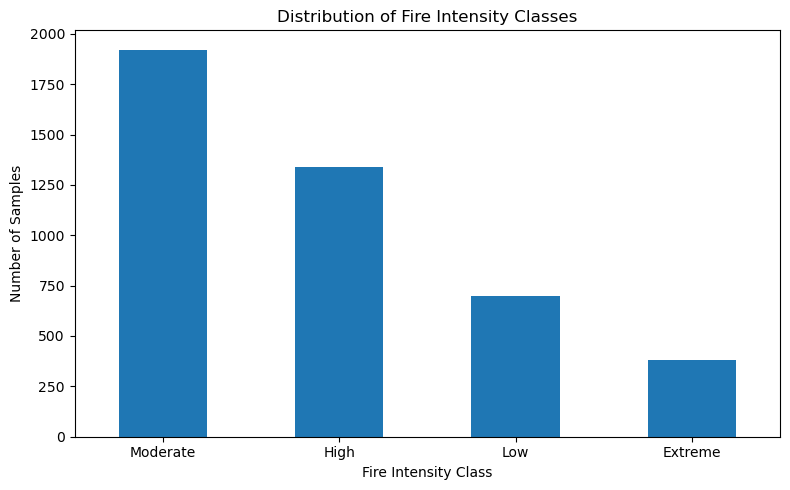

In [14]:
#plot target class distribution
plt.figure(figsize=(8, 5))
target_counts.plot(kind="bar")

plt.title("Distribution of Fire Intensity Classes")
plt.xlabel("Fire Intensity Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The target distribution shows that the dataset is not evenly balanced. Moderate fire events appear the most often, followed by High, Low, and Extreme. The Extreme class is the smallest class.

This is important for model evaluation. If I only use accuracy, the model could look good mainly because it predicts the larger classes well. However, for this wildfire task, the smaller Extreme class is still very important because it represents the highest-risk fire events. Because of this, I will use F1-score alongside accuracy when comparing models. Macro F1-score is especially useful because it gives each class equal importance.

### 4.2 Numerical feature distributions
Next, I inspect the numerical features. This helps identify whether the features have very different ranges, skewed distributions, or unusual values. This is especially relevant for SVM and Neural Network models because both are sensitive to the scale of input features.

In [15]:
#identify numerical columns from the training data
numerical_cols = train_df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Numerical columns:")
print(numerical_cols)

Numerical columns:
['latitude', 'longitude', 'acq_time', 'year', 'month', 'brightness_k', 'temp_max_c', 'wind_max_kmh', 'precip_mm', 'humidity_pct']


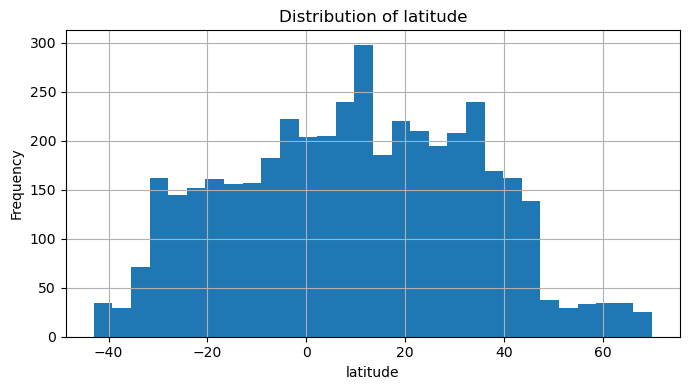

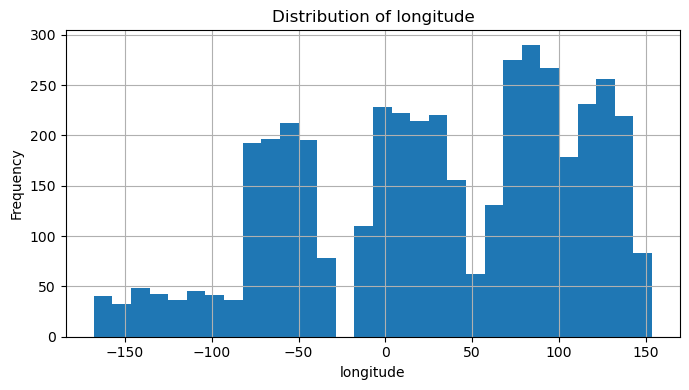

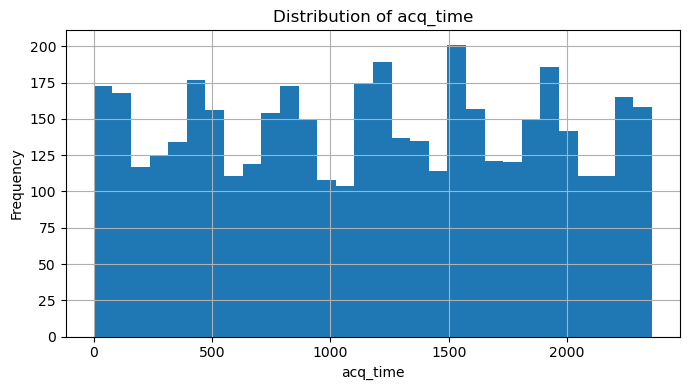

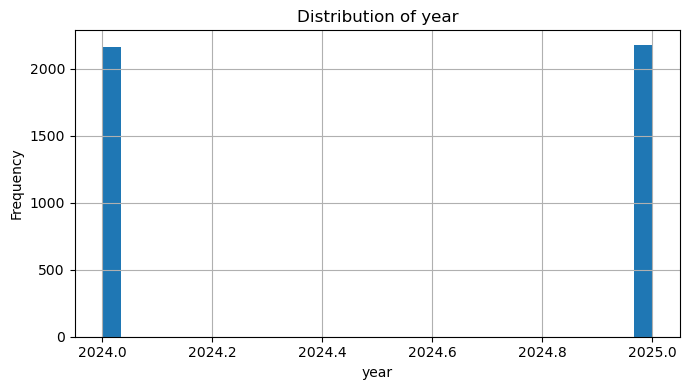

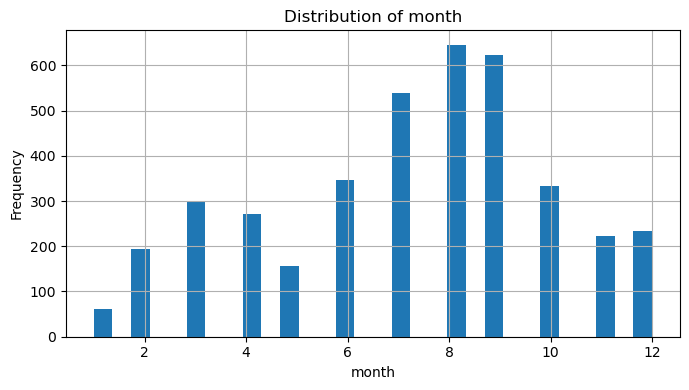

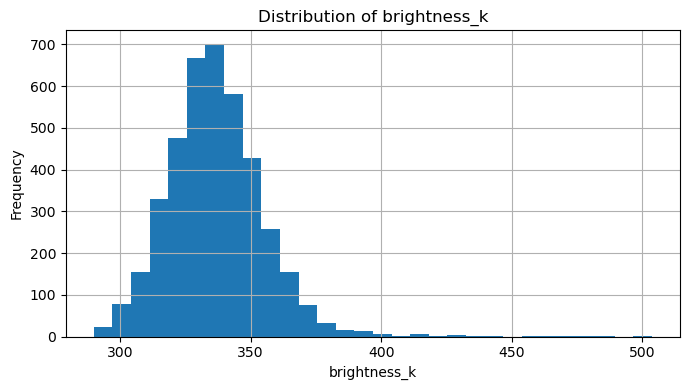

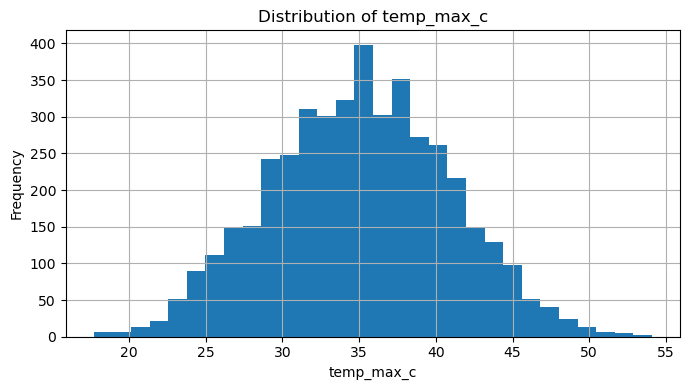

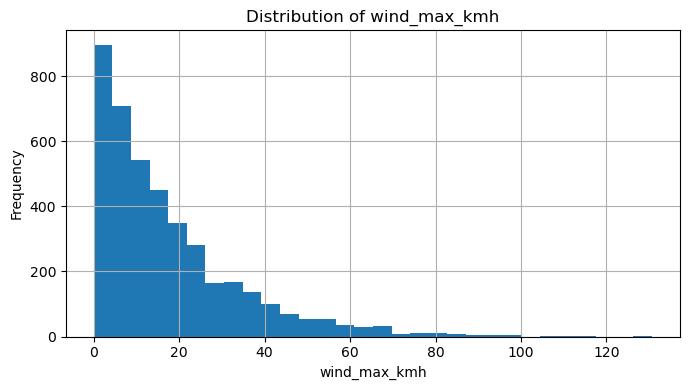

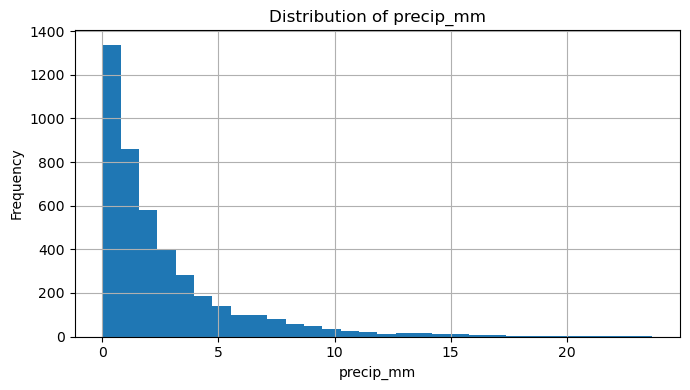

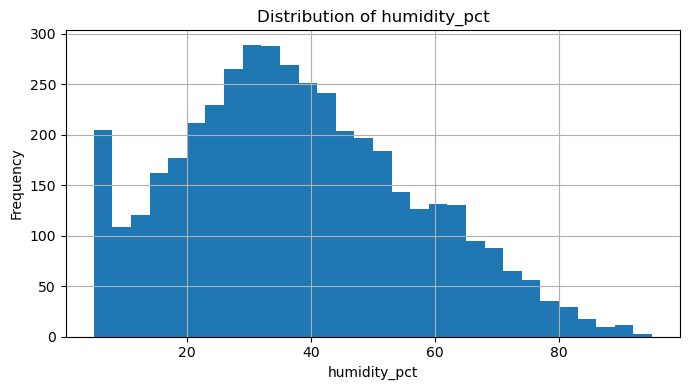

In [16]:
#plot histograms for numerical features
for col in numerical_cols:
    plt.figure(figsize=(7, 4))
    train_df[col].hist(bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

The numerical features have different ranges and distributions. For example, latitude and longitude describe location, while weather-related variables such as temperature, wind speed, precipitation, and humidity are measured on different scales. `brightness_k` is also measured in Kelvin and is directly related to satellite fire observation.

Because these features are not on the same scale, scaling will be important later for SVM and Neural Network models. Decision Trees are less affected by feature scaling, but using a consistent preprocessing workflow still helps keep the model comparison organised.

### 4.3 Categorical feature distributions
There are also some categorical variables present in the data set. The categories include information related to regions, countries, seasons, day or night, fire types, satellites, instruments, and confidence level. However, since machine learning algorithms accept only numerical data, these categorical variables must first be encoded.

In [17]:
#identify categorical columns from the training data
categorical_cols = train_df.select_dtypes(include=["object"]).columns.tolist()

#remove the target column from categorical features
if target_col in categorical_cols:
    categorical_cols.remove(target_col)

print("Categorical feature columns:")
print(categorical_cols)

print("\nNumber of unique values per categorical feature:")
train_df[categorical_cols].nunique().sort_values(ascending=False) 

Categorical feature columns:
['acq_date', 'season', 'daynight', 'region', 'country', 'fire_type', 'satellite', 'instrument', 'confidence']

Number of unique values per categorical feature:


acq_date      709
country        35
fire_type      10
region          7
season          4
satellite       4
confidence      3
daynight        2
instrument      2
dtype: int64

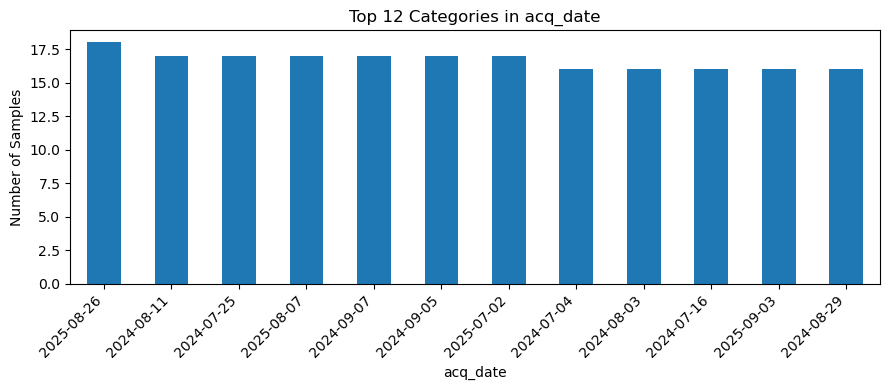

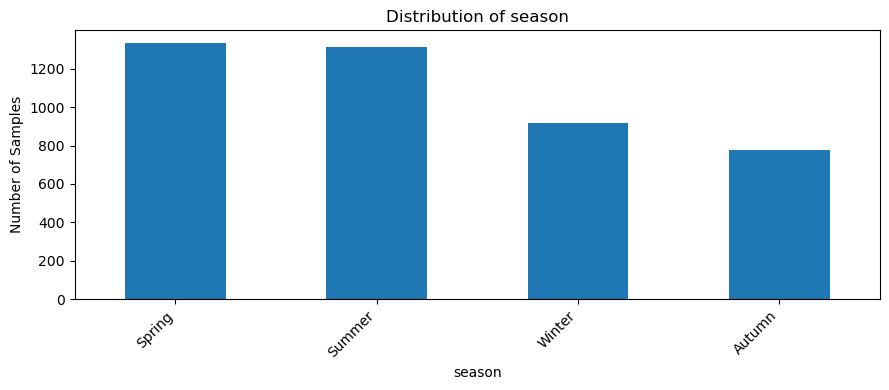

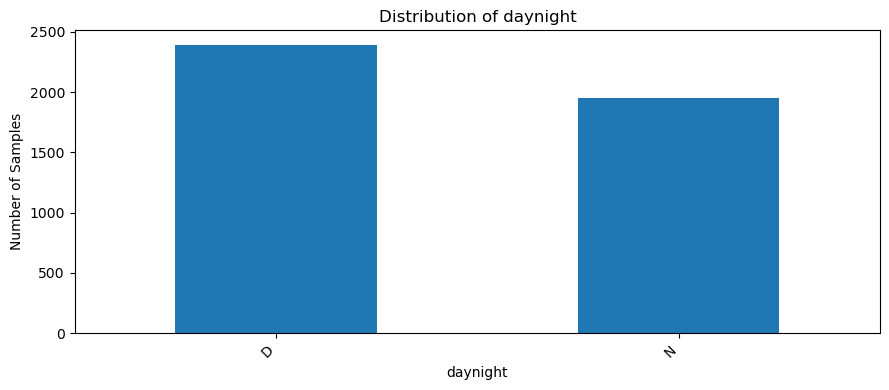

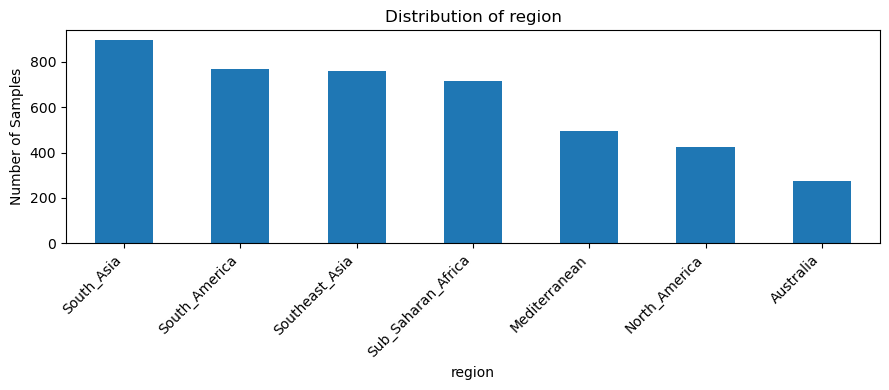

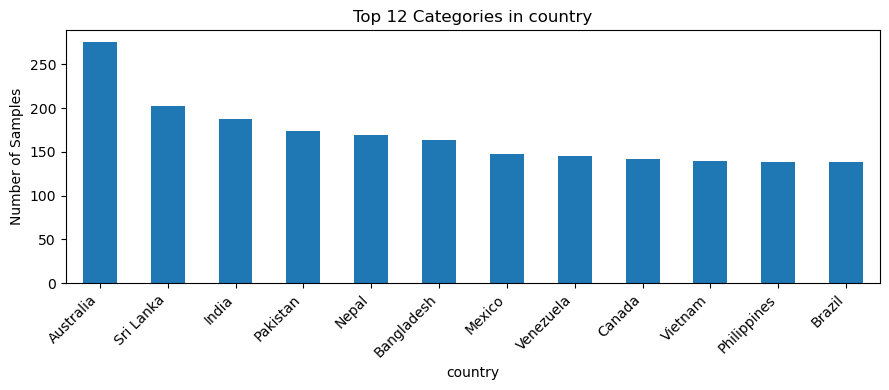

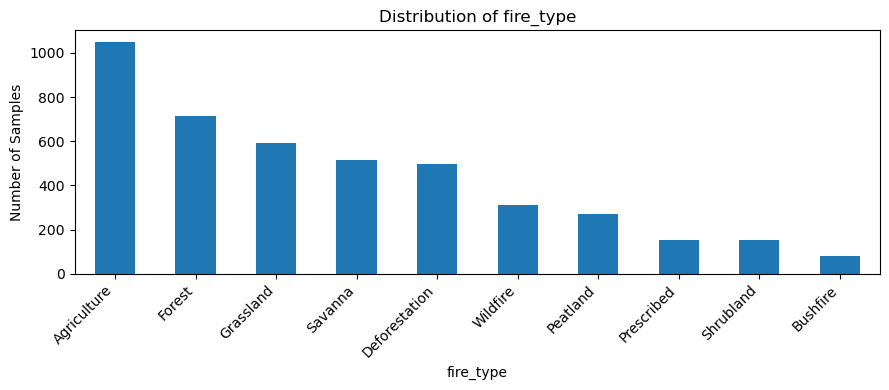

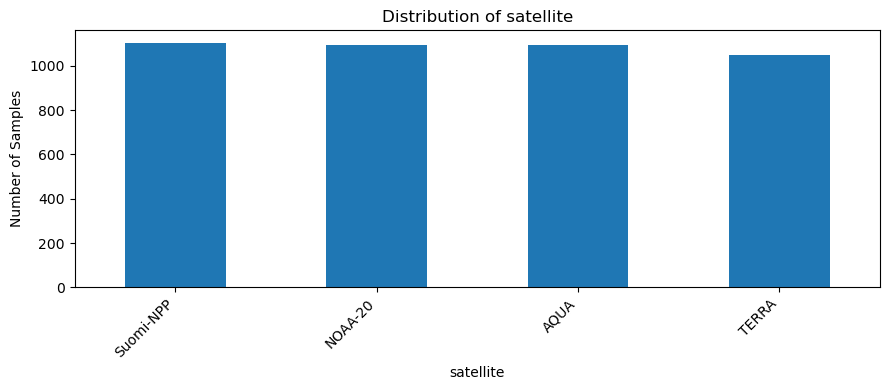

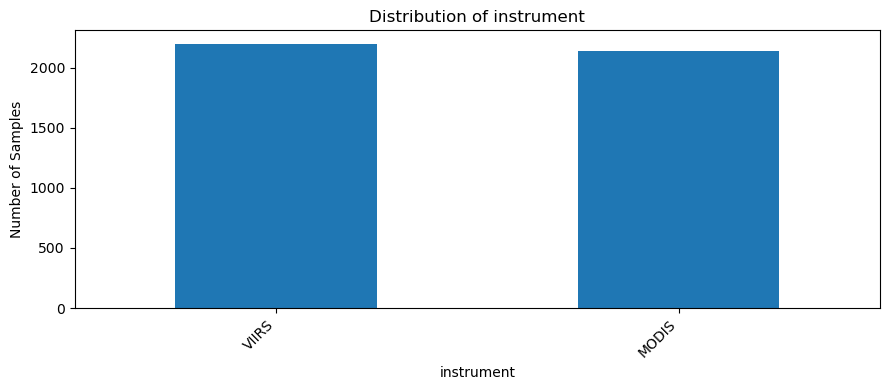

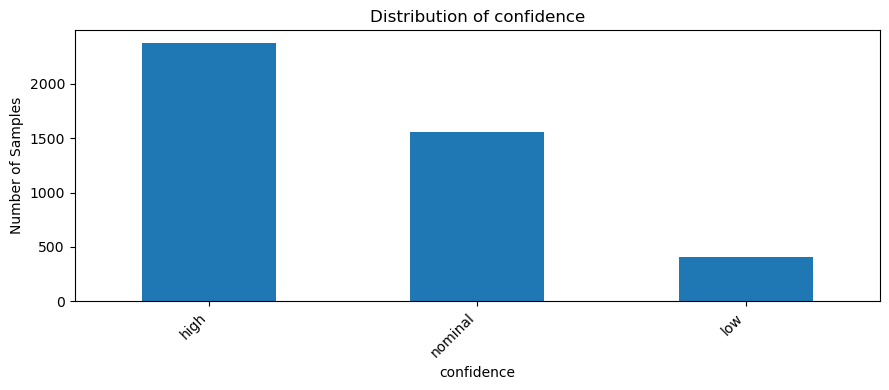

In [18]:
#plot categorical feature distributions
#for high cardinality columns, only the top categories are shown to keep plots readable
for col in categorical_cols:
    plt.figure(figsize=(9, 4))
    
    if train_df[col].nunique() > 12:
        train_df[col].value_counts().head(12).plot(kind="bar")
        plt.title(f"Top 12 Categories in {col}")
    else:
        train_df[col].value_counts().plot(kind="bar")
        plt.title(f"Distribution of {col}")
    
    plt.xlabel(col)
    plt.ylabel("Number of Samples")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

The categorical features vary in how many unique values they contain. Some features, such as `daynight` and `instrument`, only have a small number of categories. Other features, such as `country` and especially `acq_date`, have many more unique values.

This matters for preprocessing. Low-cardinality categorical features can be encoded directly using one-hot encoding. However, `acq_date` needs to be handled carefully because treating every individual date as a separate category could create too many sparse features. Since the dataset already includes `year` and `month`, I will later extract useful date-related information and avoid using the raw date string directly.

### 4.4 Feature relationships with `fire_intensity`
This section looks at how individual features relate to the target variable. This is useful because it gives an early indication of which features may help the models separate the four fire intensity classes.

For numerical features, I use boxplots to compare the distribution of each feature across fire intensity classes. For categorical features, I use class proportions to see whether some categories are more associated with certain intensity levels.

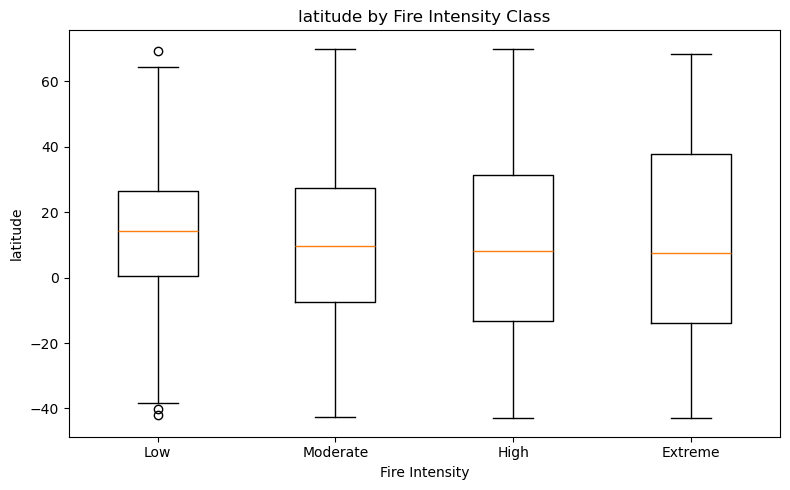

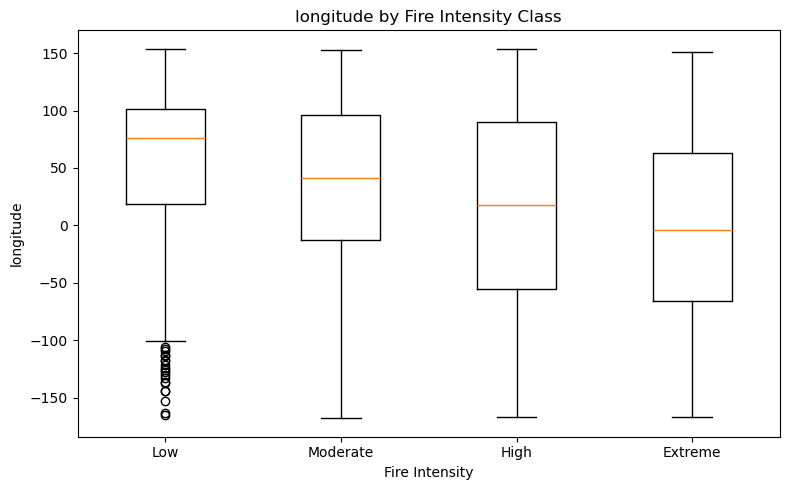

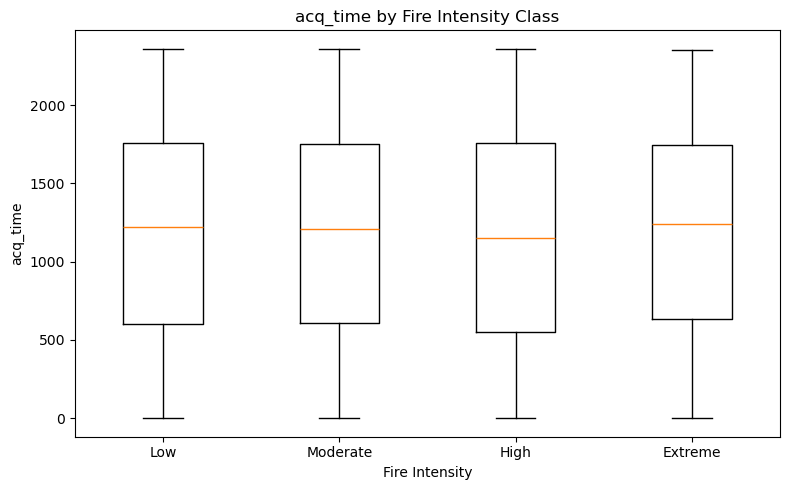

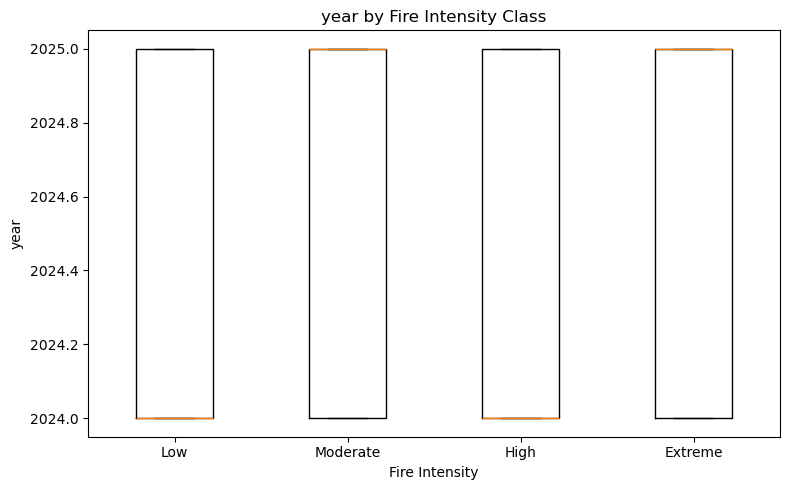

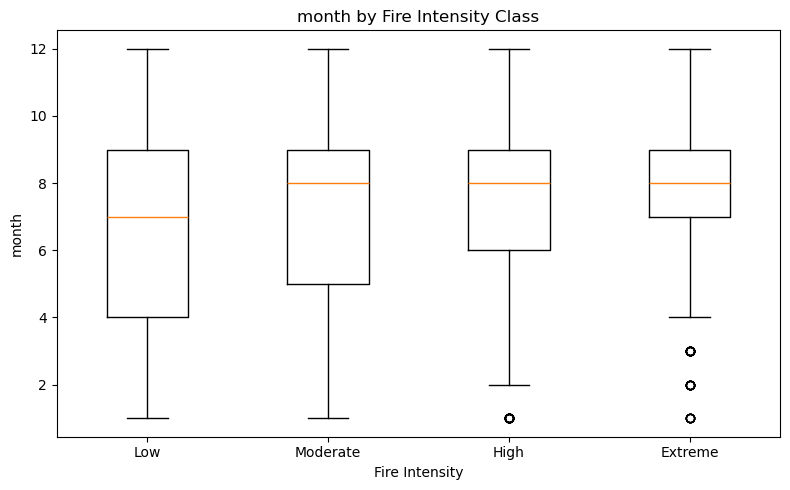

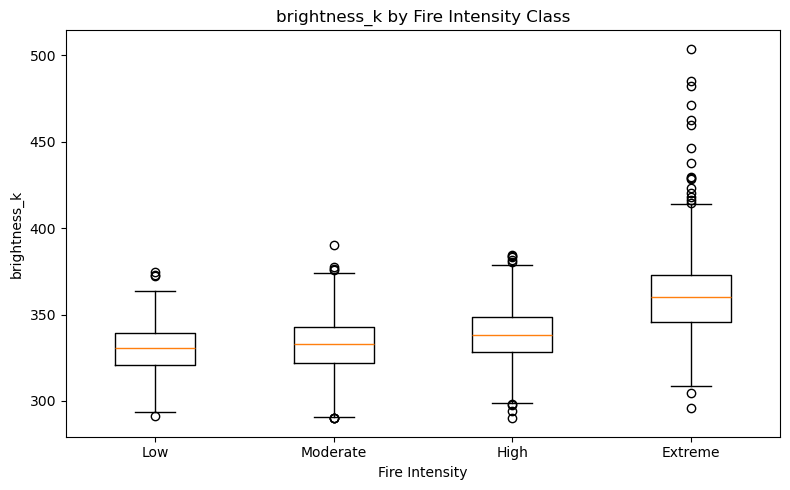

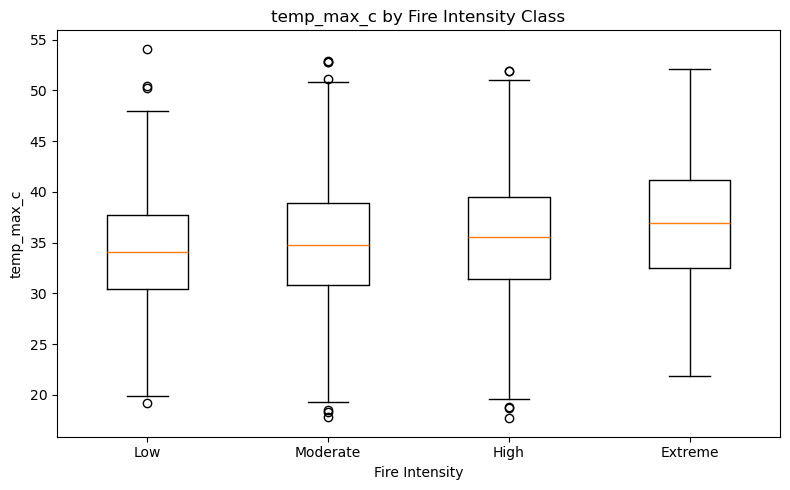

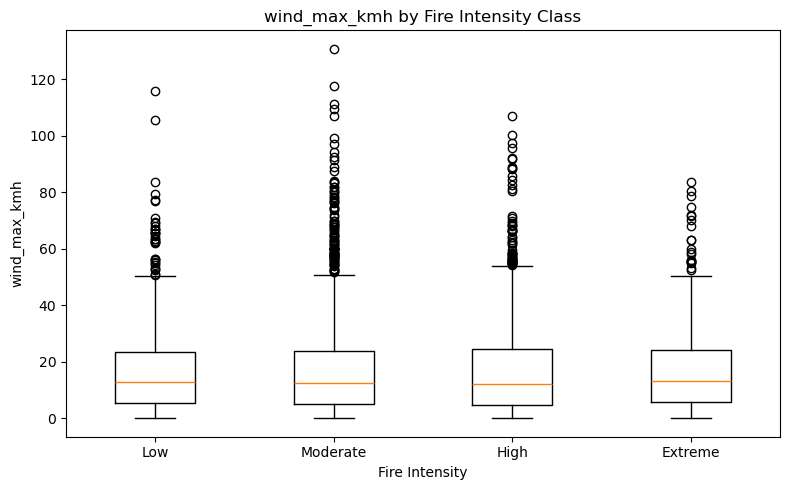

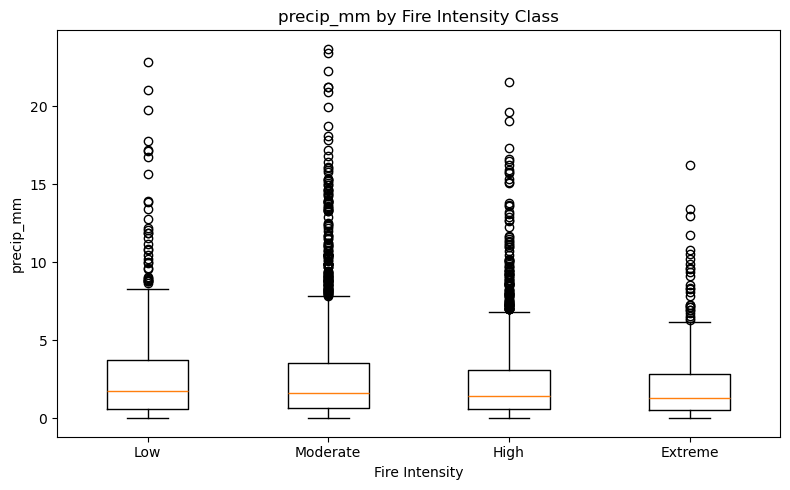

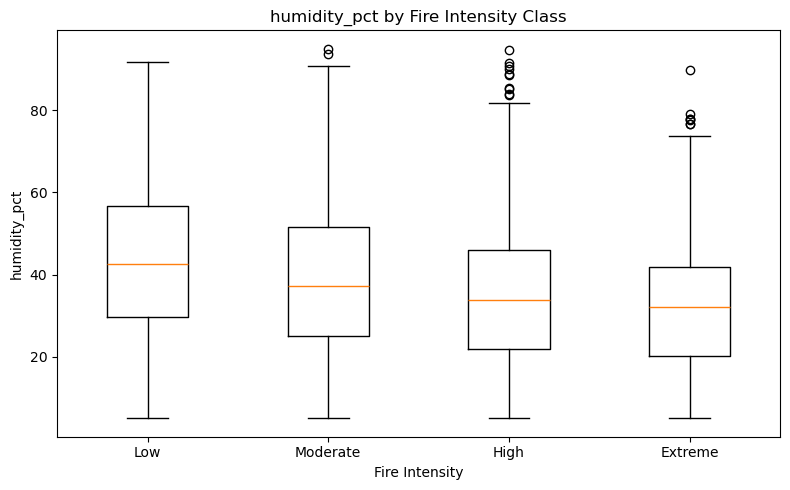

In [19]:
class_order = ["Low", "Moderate", "High", "Extreme"]

# Boxplots for numerical features against fire_intensity
for col in numerical_cols:
    plt.figure(figsize=(8, 5))
    
    data_to_plot = [
        train_df.loc[train_df[target_col] == cls, col].dropna()
        for cls in class_order
    ]
    
    plt.boxplot(data_to_plot, tick_labels=class_order)
    plt.title(f"{col} by Fire Intensity Class")
    plt.xlabel("Fire Intensity")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

The boxplots show whether the numerical features differ across the fire intensity classes. If the medians or spreads are noticeably different between classes, that feature may contain useful signal for classification.

In particular, features related to satellite observation and weather conditions are important to inspect because the assignment context suggests that fire intensity may depend on environmental and observational factors. At this stage, these plots are used as exploratory evidence. The models will later test whether these patterns are strong enough to improve validation performance.

In [20]:
#show class proportions for selected categorical features
#acq_date is excluded here because it has too many unique values to interpret clearly as raw categories
categorical_cols_for_target_analysis = [
    col for col in categorical_cols if col != "acq_date"
]

for col in categorical_cols_for_target_analysis:
    proportion_table = pd.crosstab(
        train_df[col],
        train_df[target_col],
        normalize="index"
    )
    
    # Reorder columns if all classes are present
    proportion_table = proportion_table.reindex(columns=class_order)
    
    print(f"\nClass proportions by {col}:")
    display(proportion_table.round(3))


Class proportions by season:


fire_intensity,Low,Moderate,High,Extreme
season,,,,
Autumn,0.183,0.448,0.274,0.095
Spring,0.191,0.458,0.284,0.067
Summer,0.115,0.414,0.360,0.110
Winter,0.164,0.456,0.301,0.080



Class proportions by daynight:


fire_intensity,Low,Moderate,High,Extreme
daynight,,,,
D,0.163,0.446,0.30,0.091
N,0.158,0.438,0.32,0.084



Class proportions by region:


...

fire_intensity,Low,Moderate,High,Extreme
satellite,,,,
AQUA,0.139,0.457,0.302,0.102
NOAA-20,0.182,0.414,0.320,0.083
Suomi-NPP,0.156,0.451,0.323,0.071
TERRA,0.166,0.449,0.288,0.096



Class proportions by instrument:


fire_intensity,Low,Moderate,High,Extreme
instrument,,,,
MODIS,0.152,0.453,0.295,0.099
VIIRS,0.169,0.433,0.322,0.077



Class proportions by confidence:


fire_intensity,Low,Moderate,High,Extreme
confidence,,,,
high,0.163,0.437,0.309,0.091
low,0.165,0.406,0.355,0.074
nominal,0.157,0.461,0.297,0.086


In [21]:
#show class proportions for selected categorical features
#acq_date is excluded here because it has too many unique values to interpret clearly as raw categories.
categorical_cols_for_target_analysis = [
    col for col in categorical_cols if col != "acq_date"
]

for col in categorical_cols_for_target_analysis:
    proportion_table = pd.crosstab(
        train_df[col],
        train_df[target_col],
        normalize="index"
    )
    
    # Reorder columns if all classes are present
    proportion_table = proportion_table.reindex(columns=class_order)
    
    print(f"\nClass proportions by {col}:")
    display(proportion_table.round(3))


Class proportions by season:


fire_intensity,Low,Moderate,High,Extreme
season,,,,
Autumn,0.183,0.448,0.274,0.095
Spring,0.191,0.458,0.284,0.067
Summer,0.115,0.414,0.360,0.110
Winter,0.164,0.456,0.301,0.080



Class proportions by daynight:


fire_intensity,Low,Moderate,High,Extreme
daynight,,,,
D,0.163,0.446,0.30,0.091
N,0.158,0.438,0.32,0.084



Class proportions by region:


...

fire_intensity,Low,Moderate,High,Extreme
satellite,,,,
AQUA,0.139,0.457,0.302,0.102
NOAA-20,0.182,0.414,0.320,0.083
Suomi-NPP,0.156,0.451,0.323,0.071
TERRA,0.166,0.449,0.288,0.096



Class proportions by instrument:


fire_intensity,Low,Moderate,High,Extreme
instrument,,,,
MODIS,0.152,0.453,0.295,0.099
VIIRS,0.169,0.433,0.322,0.077



Class proportions by confidence:


fire_intensity,Low,Moderate,High,Extreme
confidence,,,,
high,0.163,0.437,0.309,0.091
low,0.165,0.406,0.355,0.074
nominal,0.157,0.461,0.297,0.086


The categorical feature analysis helps show whether the target distribution changes across groups such as region, country, fire type, satellite, instrument, confidence level, season, and day/night detection.

These plots are useful because they show patterns that may not be visible from numerical correlation alone. For example, if one fire type or confidence level has a higher proportion of High or Extreme cases, that feature may help the model separate classes. I will keep these categorical features for modelling and encode them during preprocessing.

### 4.5 Correlation analysis
Correlation analysis is used to examine relationships between numerical features. This is useful for identifying features that move together and for checking which numerical features have the strongest relationship with the target.

Since `fire_intensity` is currently stored as text labels, I create a temporary encoded version only for the purpose of correlation analysis. This does not replace the original target column. 

In [22]:
#temp copy
corr_df = train_df.copy()

#temp
fire_intensity_mapping = {
    "Low": 0,
    "Moderate": 1,
    "High": 2,
    "Extreme": 3
}

corr_df["fire_intensity_encoded"] = corr_df[target_col].map(fire_intensity_mapping)

#select numerical columns plus encoded target
corr_cols = numerical_cols + ["fire_intensity_encoded"]

#calculate correlation matrix
corr_matrix = corr_df[corr_cols].corr()

corr_matrix

,latitude,longitude,acq_time,year,month,brightness_k,temp_max_c,wind_max_kmh,precip_mm,humidity_pct,fire_intensity_encoded
latitude,1.000000,-0.162653,-0.016648,0.016765,-0.056566,-0.003897,0.057751,-0.016326,0.008045,-0.028769,-0.029989
longitude,-0.162653,1.000000,0.005183,0.022066,-0.279263,-0.094968,-0.158327,0.026428,0.176069,0.462007,-0.215381
acq_time,-0.016648,0.005183,1.000000,-0.003629,-0.010849,0.036044,-0.002655,0.034678,0.008094,-0.002623,0.008953
year,0.016765,0.022066,-0.003629,1.000000,-0.000822,0.013378,0.036890,-0.011904,-0.015466,0.007842,0.013294
month,-0.056566,-0.279263,-0.010849,-0.000822,1.000000,0.029458,0.476214,-0.007922,-0.091979,-0.213558,0.066834
brightness_k,-0.003897,-0.094968,0.036044,0.013378,0.029458,1.000000,0.049028,-0.020866,-0.009681,-0.050409,0.388928
temp_max_c,0.057751,-0.158327,-0.002655,0.036890,0.476214,0.049028,1.000000,0.005850,-0.117732,-0.263318,0.118841
wind_max_kmh,-0.016326,0.026428,0.034678,-0.011904,-0.007922,-0.020866,0.005850,1.000000,0.013134,0.017510,0.002287
precip_mm,0.008045,0.176069,0.008094,-0.015466,-0.091979,-0.009681,-0.117732,0.013134,1.000000,0.347163,-0.059050
humidity_pct,-0.028769,0.462007,-0.002623,0.007842,-0.213558,-0.050409,-0.263318,0.017510,0.347163,1.000000,-0.163306


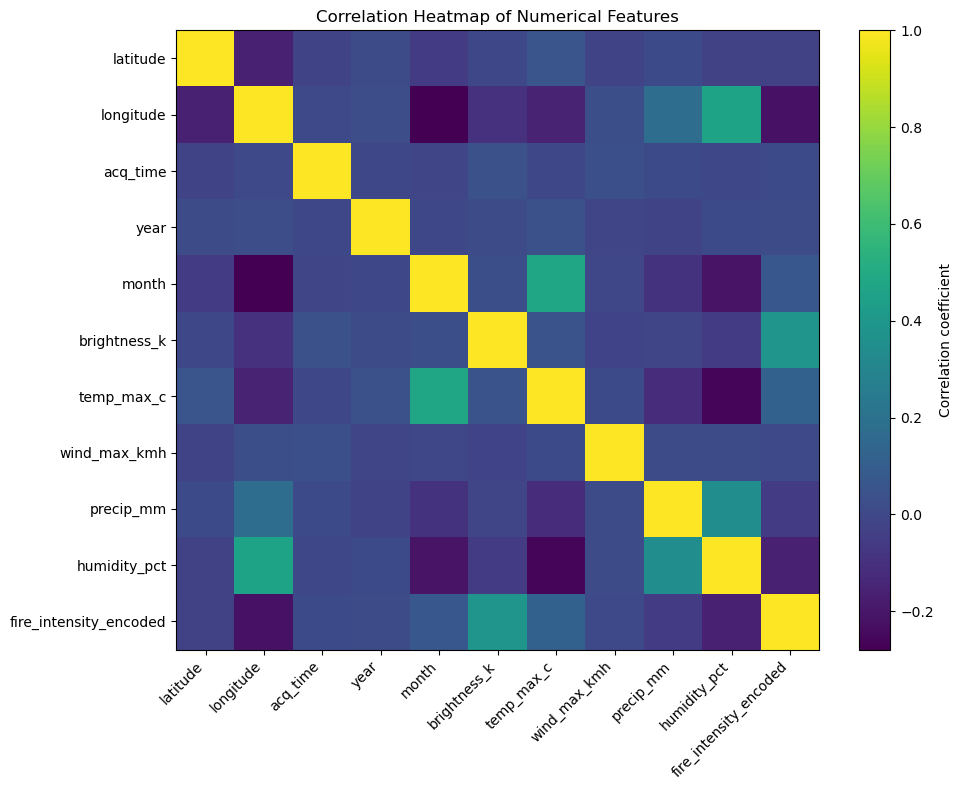

In [23]:
#plot correlation heatmap using matplotlib
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation coefficient")

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

In [24]:
#rank numerical features by absolute correlation with the encoded target
target_corr = corr_matrix["fire_intensity_encoded"].drop("fire_intensity_encoded")
target_corr_ranked = target_corr.reindex(target_corr.abs().sort_values(ascending=False).index)

target_corr_table = pd.DataFrame({
    "correlation_with_fire_intensity": target_corr_ranked,
    "absolute_correlation": target_corr_ranked.abs()
})

target_corr_table

,correlation_with_fire_intensity,absolute_correlation
brightness_k,0.388928,0.388928
longitude,-0.215381,0.215381
humidity_pct,-0.163306,0.163306
temp_max_c,0.118841,0.118841
month,0.066834,0.066834
precip_mm,-0.059050,0.059050
latitude,-0.029989,0.029989
year,0.013294,0.013294
acq_time,0.008953,0.008953
wind_max_kmh,0.002287,0.002287


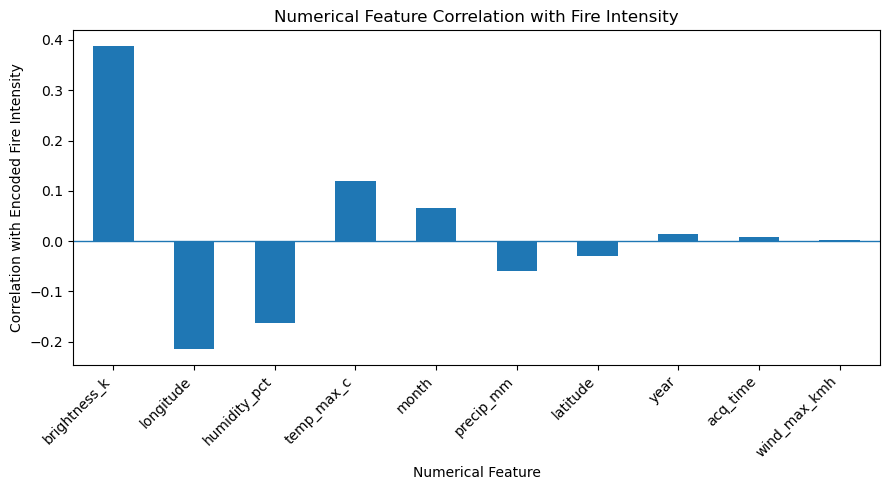

In [25]:
#plot ranked correlations with the target
plt.figure(figsize=(9, 5))
target_corr_ranked.plot(kind="bar")

plt.title("Numerical Feature Correlation with Fire Intensity")
plt.xlabel("Numerical Feature")
plt.ylabel("Correlation with Encoded Fire Intensity")
plt.xticks(rotation=45, ha="right")
plt.axhline(0, linewidth=1)
plt.tight_layout()
plt.show()

The ranked correlation table is more useful than only showing a heatmap because it makes the feature-target relationships clearer. It shows which numerical features have the strongest linear relationship with the encoded fire intensity target.

However, correlation should not be treated as the full answer. A low correlation does not automatically mean a feature is useless, because the relationship may be non-linear or may only become useful when combined with other features. This is especially relevant for models such as Decision Trees, RBF SVM, and Neural Networks, which can capture more complex patterns than simple linear relationships.

The correlation analysis is still useful because it gives an evidence-based starting point for understanding the dataset and discussing which features appear more directly related to fire intensity.

### 4.6 Key exploratory data analysis findings
The exploratory data analysis gives several useful findings for the modelling stage:

- The target variable is imbalanced. Moderate and High fires appear more often, while Extreme fires are less common.
- Because of this imbalance, accuracy alone is not enough. Macro F1-score will be used to give more balanced attention to each class.
- The dataset contains both numerical and categorical features, so preprocessing must include imputation, encoding, and scaling.
- Numerical features have different ranges, which supports the use of scaling for SVM and Neural Network models.
- Some categorical features appear to change the class proportions of `fire_intensity`, so they may provide useful classification signal.
- The correlation ranking helps identify which numerical features have stronger linear relationships with the target, but it does not capture every possible relationship.
- Features with weak linear correlation may still be useful for non-linear models, especially when combined with other features.

Overall, the EDA suggests that this task is not simply about one dominant predictor. The models will likely need to use a combination of satellite observations, weather variables, location information, and categorical descriptors to predict wildfire intensity.

## 5. Data preprocessing
This section prepares the dataset for modelling. The raw dataset contains a mix of numerical, categorical, date, and time-based features, so the data needs to be transformed before it can be used by the three machine learning models.

The preprocessing steps include:

- separating the input features from the target variable
- encoding the target labels into the required numeric format
- extracting useful information from date and time columns
- identifying numerical and categorical features
- handling missing values
- encoding categorical variables
- scaling numerical variables
- building a reusable preprocessing pipeline

I use a pipeline-based approach so that the same transformations can be applied consistently during training, validation, and final test prediction.

### 5.1 Separate features and target

The first step is to separate the input features from the prediction target. The input features are stored in `X`, while the target variable `fire_intensity` is stored separately.

The test dataset is also copied into `X_test` so that it can go through the same preprocessing steps later. 

In [26]:
#separate input features and target from the training dataset
X = train_df.drop(columns=[target_col]).copy()
y_text = train_df[target_col].copy()

#copy test features
X_test = test_df.copy()

print("Training feature shape:", X.shape)
print("Target shape:", y_text.shape)
print("Test feature shape:", X_test.shape)

Training feature shape: (4340, 19)
Target shape: (4340,)
Test feature shape: (1085, 19)


### 5.2 Encode target labels
The target column is currently stored as text labels. For modelling and final prediction output, I encode the labels into the numeric format required by the assignment:

- Low = 0
- Moderate = 1
- High = 2
- Extreme = 3

This mapping keeps the class order meaningful, from lowest to highest wildfire intensity 

In [27]:
#target encoding
fire_intensity_mapping = {
    "Low": 0,
    "Moderate": 1,
    "High": 2,
    "Extreme": 3
}

#reverse mapping 
fire_intensity_reverse_mapping = {
    0: "Low",
    1: "Moderate",
    2: "High",
    3: "Extreme"
}

#encode target labels
y = y_text.map(fire_intensity_mapping)

#check that all target values were mapped correctly
print("Missing encoded target values:", y.isnull().sum())
print("\nEncoded target distribution:")
print(y.value_counts().sort_index())

Missing encoded target values: 0

Encoded target distribution:
fire_intensity
0     698
1    1921
2    1340
3     381
Name: count, dtype: int64


The target labels have now been converted into numeric classes. I also check for missing encoded values to make sure there were no unexpected target labels in the dataset.

### 5.3 Handle date/time features

The dataset contains `acq_date` and `acq_time`, which describe when the fire was detected. These features are useful, but they should not be used in their raw form.

For `acq_date`, treating every date as a separate category would create too many sparse features and would not be very meaningful. Instead, I extract simple date-based features such as day of month and day of year.

For `acq_time`, the raw value is in HHMM format. This means it should not be treated as a normal continuous number. I split it into hour and minute so the model can use the time information in a cleaner way.

I also use `acq_date` to fill missing values in `month` where possible, because the date itself contains the month information.

In [28]:
def process_date_time_features(df):
    df = df.copy()
    df["acq_date_parsed"] = pd.to_datetime(df["acq_date"], errors="coerce")
    
    df["acq_day"] = df["acq_date_parsed"].dt.day
    df["acq_dayofyear"] = df["acq_date_parsed"].dt.dayofyear
    
    if "month" in df.columns:
        df["month"] = df["month"].fillna(df["acq_date_parsed"].dt.month)
        
    acq_time_str = df["acq_time"].astype("Int64").astype(str).str.zfill(4)
    
    df["acq_hour"] = pd.to_numeric(acq_time_str.str[:2], errors="coerce")
    df["acq_minute"] = pd.to_numeric(acq_time_str.str[2:], errors="coerce")
    
    df = df.drop(columns=["acq_date", "acq_date_parsed", "acq_time"])
    
    return df

In [29]:
#apply date/time processing to training and test features
X_processed = process_date_time_features(X)
X_test_processed = process_date_time_features(X_test)

print("Processed training feature shape:", X_processed.shape)
print("Processed test feature shape:", X_test_processed.shape)

print("\nProcessed columns:")
print(list(X_processed.columns))

Processed training feature shape: (4340, 21)
Processed test feature shape: (1085, 21)

Processed columns:
['latitude', 'longitude', 'year', 'month', 'season', 'daynight', 'region', 'country', 'fire_type', 'satellite', 'instrument', 'brightness_k', 'confidence', 'temp_max_c', 'wind_max_kmh', 'precip_mm', 'humidity_pct', 'acq_day', 'acq_dayofyear', 'acq_hour', 'acq_minute']


After this step, the raw `acq_date` and `acq_time` columns have been replaced with cleaner date/time features. This keeps the useful timing information while avoiding problems caused by raw date strings or HHMM values.

### 5.4 Identify numerical and categorical columns

After handling the date and time features, I identify which columns are numerical and which are categorical. This is needed because the two feature types require different preprocessing steps.

In [30]:
#identify numerical and categorical columns after date/time processing
numerical_cols = X_processed.select_dtypes(include=["int64", "float64", "Int64"]).columns.tolist()
categorical_cols = X_processed.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

print("\nNumber of numerical columns:", len(numerical_cols))
print("Number of categorical columns:", len(categorical_cols))

Numerical columns:
['latitude', 'longitude', 'year', 'month', 'brightness_k', 'temp_max_c', 'wind_max_kmh', 'precip_mm', 'humidity_pct', 'acq_hour', 'acq_minute']

Categorical columns:
['season', 'daynight', 'region', 'country', 'fire_type', 'satellite', 'instrument', 'confidence']

Number of numerical columns: 11
Number of categorical columns: 8


The numerical columns will be imputed and scaled. The categorical columns will be imputed and one-hot encoded. This keeps the preprocessing appropriate for each type of feature.

### 5.5 Handle missing values
Missing values are handled inside the preprocessing pipeline rather than manually changing the dataset. This is safer because the imputation values are learned from the training data and then applied consistently to validation and test data.

For numerical features, I use median imputation. I chose the median because it is less affected by unusually high or low values than the mean. For categorical features, I use the most frequent category.

In [31]:
missing_after_processing = X_processed.isnull().sum()
missing_after_processing = missing_after_processing[missing_after_processing > 0].sort_values(ascending=False)

print("Missing values after date/time processing:")
missing_after_processing

Missing values after date/time processing:


brightness_k    327
wind_max_kmh    207
dtype: int64

### 5.6 Encode categorical variables
The categorical variables need to be converted into numerical form before they can be used by the models. I use one-hot encoding because the categorical features do not have a natural numeric order.

For example, categories such as region, country, fire type, and satellite should not be treated as if one category is mathematically larger than another. One-hot encoding avoids this problem by creating separate binary columns for each category.

### 5.7 Scale numerical features

Numerical scaling is included because SVM and Neural Network models are sensitive to the magnitude of input features. Without scaling, features with larger numeric ranges could have a stronger influence on the model than intended.

I use standardisation with `StandardScaler`, which transforms numerical features so they are centred around zero with a standard deviation of one.

Decision Trees do not require feature scaling in the same way, but using a consistent preprocessing structure makes the experiments easier to manage and compare.

### 5.8 Build preprocessing pipeline

The preprocessing pipeline combines missing value handling, categorical encoding, and numerical scaling into one reusable object.

The numerical pipeline applies:

1. median imputation
2. standard scaling

The categorical pipeline applies:

1. most-frequent imputation
2. one-hot encoding

These are combined using `ColumnTransformer`, which applies the correct preprocessing steps to the correct feature columns.

In [32]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


### 5.9 Preprocessing summary

The preprocessing stage prepares the data in a way that is suitable for all three required models.

The main decisions made in this section are:

- The target labels were encoded into the required numeric format from 0 to 3.
- Raw date and time columns were converted into more useful features.
- Missing numerical values will be handled using median imputation.
- Missing categorical values will be handled using the most frequent category.
- Categorical features will be one-hot encoded.
- Numerical features will be scaled using standardisation.
- All preprocessing steps are stored in a reusable pipeline.

This setup helps avoid inconsistent preprocessing between training, validation, and test prediction. It also reduces the risk of data leakage because the imputation and scaling steps will be fitted only on the training portion after the train-validation split.

### 5.8 Build preprocessing pipeline

The preprocessing pipeline combines missing value handling, categorical encoding, and numerical scaling into one reusable object.

The numerical pipeline applies:

1. median imputation
2. standard scaling

The categorical pipeline applies:

1. most-frequent imputation
2. one-hot encoding

These are combined using `ColumnTransformer`, which applies the correct preprocessing steps to the correct feature columns.

The numerical columns will be imputed and scaled. The categorical columns will be imputed and one-hot encoded. This keeps the preprocessing appropriate for each type of feature.

## 6. Train-validation split
The provided labelled dataset, `wildfire_cls_train_full.csv`, is used for model development. This dataset contains both the input features and the target variable `fire_intensity`.

The provided test dataset, `wildfire_cls_test_features.csv`, is not used for model selection because it does not contain the target labels. Since there are no true `fire_intensity` values in the test dataset, I cannot calculate validation accuracy, F1-score, or a confusion matrix from it. Therefore, I only use the test dataset at the end of the notebook to generate the final prediction CSV.

To evaluate and compare models properly, I split the labelled training dataset into a training set and a validation set. The training set is used to fit the models, while the validation set is used for hyperparameter selection and model comparison.

I use an 80/20 train-validation split with stratification. Stratification keeps the class distribution of Low, Moderate, High, and Extreme similar in both the training and validation sets, which is important because the target classes are not perfectly balanced.

### 6.1 Split strategy
The processed features from `wildfire_cls_train_full.csv` are stored in `X_processed`, and the encoded target values are stored in `y`. These are split into training and validation sets.

The processed test dataset is stored separately as `X_test_processed`. It is not used in this split because it does not contain labels.

In [33]:
#split the labelled training dataset into training and validation sets
#wildfire_cls_train_full.csv
X_train, X_val, y_train, y_val = train_test_split(
    X_processed,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Source dataset: wildfire_cls_train_full.csv")
print("Training feature shape:", X_train.shape)
print("Validation feature shape:", X_val.shape)
print("Training target shape:", y_train.shape)
print("Validation target shape:", y_val.shape)

print("\nHeld-out test dataset for final prediction only:")
print("Source dataset: wildfire_cls_test_features.csv")
print("Processed test feature shape:", X_test_processed.shape)

Source dataset: wildfire_cls_train_full.csv
Training feature shape: (3472, 21)
Validation feature shape: (868, 21)
Training target shape: (3472,)
Validation target shape: (868,)

Held-out test dataset for final prediction only:
Source dataset: wildfire_cls_test_features.csv
Processed test feature shape: (1085, 21)


In [34]:
#check class distribution after splitting the labelled training dataset
split_distribution = pd.DataFrame({
    "Full labelled dataset (%)": y.value_counts(normalize=True).sort_index() * 100,
    "Training set (%)": y_train.value_counts(normalize=True).sort_index() * 100,
    "Validation set (%)": y_val.value_counts(normalize=True).sort_index() * 100
})

split_distribution = split_distribution.round(2)
split_distribution.index = ["Low", "Moderate", "High", "Extreme"]

split_distribution

,Full labelled dataset (%),Training set (%),Validation set (%)
Low,16.08,16.07,16.13
Moderate,44.26,44.27,44.24
High,30.88,30.88,30.88
Extreme,8.78,8.78,8.76


The class percentages are very similar across the full labelled dataset, training set, and validation set. This confirms that the stratified split worked as intended. This matters because the Extreme class has fewer examples than the other classes. Without stratification, the validation set might contain a less representative class distribution, which would make model comparison less reliable.

### 6.2 Evaluation metrics
The models are evaluated using the validation split from `wildfire_cls_train_full.csv`. I use multiple metrics because this is a multi-class classification problem and the target classes are not perfectly balanced.

The main metrics are:

- **Accuracy**: the overall proportion of correct predictions.
- **Macro F1-score**: the average F1-score across all classes, treating each class equally.
- **Weighted F1-score**: the average F1-score weighted by the number of samples in each class.
- **Confusion matrix**: shows which classes are predicted correctly and which classes are confused with each other.
- **Classification report**: gives precision, recall, and F1-score for each individual class.

Accuracy is useful, but it can hide weak performance on smaller classes. Macro F1-score is especially important here because it gives Low, Moderate, High, and Extreme equal importance during evaluation.

### 6.3 Evaluation helper functions
To keep the experiments consistent, I define helper functions for evaluating models. The same functions are used for Decision Tree, SVM, and Neural Network, which helps make the comparison fair. The models are evaluated on the validation split from the labelled training data, not on the provided test dataset.

In [35]:
class_names = ["Low", "Moderate", "High", "Extreme"]

def evaluate_predictions(y_true, y_pred):
    """
    Calculate the main classification metrics used in this notebook.
    """
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted")
    }


def evaluate_model(model, X_train, y_train, X_val, y_val, model_name):
    """
    Fit a model using the training split from wildfire_cls_train_full.csv,
    then evaluate it on the validation split from the same labelled dataset.
    """
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    
    train_metrics = evaluate_predictions(y_train, train_pred)
    val_metrics = evaluate_predictions(y_val, val_pred)
    
    results = {
        "model": model_name,
        "train_accuracy": train_metrics["accuracy"],
        "val_accuracy": val_metrics["accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "val_macro_f1": val_metrics["macro_f1"],
        "train_weighted_f1": train_metrics["weighted_f1"],
        "val_weighted_f1": val_metrics["weighted_f1"]
    }
    
    return results, train_pred, val_pred


def show_classification_report(y_true, y_pred):
    """
    Display precision, recall, and F1-score for each fire intensity class.
    zero_division=0 prevents warnings when a model predicts no samples for a class.
    """
    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    ))


def plot_confusion_matrix(y_true, y_pred, title):
    """
    Plot a confusion matrix using the class names in the correct order.
    """
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3])
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )
    
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, values_format="d")
    plt.title(title)
    plt.tight_layout()
    plt.show()

### 6.4 Why the provided test dataset is not used for model selection
The provided test dataset, `wildfire_cls_test_features.csv`, is not used to choose hyperparameters or compare models because it does not include the true `fire_intensity` labels.

Model selection needs known target labels so that performance metrics such as accuracy, macro F1-score, and confusion matrices can be calculated. Since the test dataset has no labels, it cannot be used for this purpose.

Instead, the labelled training dataset is split into training and validation sets. The validation set acts as the labelled held-out data for model comparison. After the final model is selected, the model is retrained using the full labelled training dataset and then applied to `wildfire_cls_test_features.csv` to generate the final prediction CSV.

This follows the assignment requirement to design an evaluation framework using the training data and then predict the fire intensity level for the test set.

### 6.5 Preprocessing inside model pipelines
The `preprocessor` created earlier will be included inside each model pipeline. This means the same missing value handling, encoding, and scaling steps are applied before the model is trained.

This is important because the preprocessing steps should be learned only from the training split, then applied to the validation split. Doing this inside a pipeline reduces the risk of data leakage and makes the workflow easier to reproduce.

### 6.6 Result storage

I create empty lists to store model results. These tables will be built up during the Decision Tree, SVM, and Neural Network experiments, then used later for model comparison.

In [36]:
# Lists for storing experiment results
all_model_results = []
decision_tree_results = []
svm_results = []
nn_results = []

print("Result storage lists created.")

Result storage lists created.


### 6.7 Train-validation setup summary
The evaluation setup is now ready. The labelled training data from `wildfire_cls_train_full.csv` has been split into training and validation sets using a stratified 80/20 split. The validation set will be used for hyperparameter selection and model comparison.

For each model, I will compare both training and validation performance. This helps identify underfitting and overfitting:

- If both training and validation scores are low, the model may be underfitting.
- If training scores are high but validation scores are much lower, the model may be overfitting.
- If validation performance is strong and close to training performance, the model is more likely to generalise well.

The provided test dataset, `wildfire_cls_test_features.csv`, remains untouched for model selection and will only be used after the final model has been chosen.

## 7. Decision Tree
The first model I develop is a Decision Tree classifier. I use it as the first model because it is relatively easy to understand and interpret. A Decision Tree works by repeatedly splitting the feature space into smaller regions, so it can capture threshold-style patterns in the data.
For this wildfire dataset, a Decision Tree may be useful because fire intensity could depend on split-like conditions, such as brightness temperature being above a certain level, humidity being low, or confidence level being high. However, Decision Trees can also overfit if they are allowed to grow too deep. A very deep tree may learn very specific patterns in the training data that do not generalise well to validation data.
Because of this, I test different values of `max_depth`. This allows me to study how model complexity affects training and validation performance.

### 7.1 Baseline Decision Tree
I start with a baseline Decision Tree using the default settings. This gives an initial reference point before tuning the model.

The baseline model is useful because it shows what happens when the tree is allowed to grow without a depth restriction. If the training score is much higher than the validation score, that would suggest overfitting.

In [37]:
#baseline dt pipeline
dt_baseline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))
])

#evaluate baseline DT
dt_baseline_results, dt_train_pred, dt_val_pred = evaluate_model(
    dt_baseline,
    X_train,
    y_train,
    X_val,
    y_val,
    "Decision Tree Baseline"
)

pd.DataFrame([dt_baseline_results])

,model,train_accuracy,val_accuracy,train_macro_f1,val_macro_f1,train_weighted_f1,val_weighted_f1
0,Decision Tree Baseline,1.0,0.375576,1.0,0.325011,1.0,0.372147


Baseline Decision Tree - Validation Classification Report
              precision    recall  f1-score   support

         Low     0.2110    0.1643    0.1847       140
    Moderate     0.4707    0.4818    0.4762       384
        High     0.3310    0.3545    0.3423       268
     Extreme     0.2911    0.3026    0.2968        76

    accuracy                         0.3756       868
   macro avg     0.3260    0.3258    0.3250       868
weighted avg     0.3700    0.3756    0.3721       868



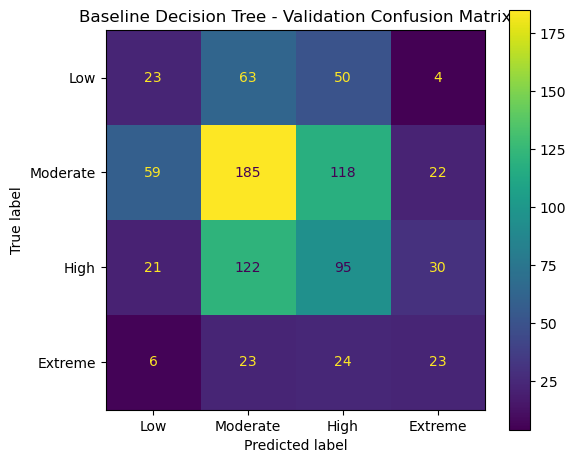

In [38]:
print("Baseline Decision Tree - Validation Classification Report")
show_classification_report(y_val, dt_val_pred)

plot_confusion_matrix(
    y_val,
    dt_val_pred,
    "Baseline Decision Tree - Validation Confusion Matrix"
)

The baseline Decision Tree gives an initial view of how a single unrestricted tree performs. If the model has a much stronger training score than validation score, this indicates that the tree is likely overfitting. This is why tuning `max_depth` is important. By limiting the depth of the tree, I can reduce model complexity and check whether a simpler tree generalises better to the validation set.

### 7.2 Hyperparameter experiment: `max_depth`
The main hyperparameter tested for the Decision Tree is `max_depth`. This controls how many levels the tree is allowed to grow.

A shallow tree has lower complexity. It may be easier to interpret, but it can underfit if it is too simple to capture the relationship between the features and fire intensity.

A deeper tree has higher complexity. It can capture more detailed patterns, but it may overfit if it learns noise or patterns that are too specific to the training data.

I test several values of `max_depth` and compare both training and validation performance. The best value is selected mainly using validation macro F1-score, because macro F1 gives each fire intensity class equal importance.

In [39]:
#test different max_depth values for DT
max_depth_values = [2, 3, 4, 5, 6, 8, 10, 12, None]

decision_tree_results = []
decision_tree_models = {}

for depth in max_depth_values:
    model_name = f"Decision Tree max_depth={depth}"
    
    dt_model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            max_depth=depth,
            random_state=RANDOM_STATE
        ))
    ])
    
    results, train_pred, val_pred = evaluate_model(
        dt_model,
        X_train,
        y_train,
        X_val,
        y_val,
        model_name
    )
    
    results["max_depth"] = depth
    decision_tree_results.append(results)
    decision_tree_models[depth] = dt_model

#convert results to DataFrame
dt_results_df = pd.DataFrame(decision_tree_results)

#show results sorted by validation macro F1
dt_results_df.sort_values(by="val_macro_f1", ascending=False)

,model,train_accuracy,val_accuracy,train_macro_f1,val_macro_f1,train_weighted_f1,val_weighted_f1,max_depth
1,Decision Tree max_depth=3,0.479263,0.461982,0.373706,0.356689,0.437003,0.420562,3.0
4,Decision Tree max_depth=6,0.533986,0.471198,0.419885,0.337223,0.471263,0.402996,6.0
5,Decision Tree max_depth=8,0.579781,0.444700,0.511845,0.334788,0.543748,0.397082,8.0
7,Decision Tree max_depth=12,0.710829,0.407834,0.690862,0.333657,0.700648,0.386904,12.0
3,Decision Tree max_depth=5,0.511521,0.478111,0.372572,0.331445,0.435328,0.399483,5.0
8,Decision Tree max_depth=None,1.000000,0.375576,1.000000,0.325011,1.000000,0.372147,NaN
2,Decision Tree max_depth=4,0.492512,0.471198,0.343135,0.322792,0.402914,0.377788,4.0
6,Decision Tree max_depth=10,0.644873,0.408986,0.592976,0.296764,0.615584,0.356416,10.0
0,Decision Tree max_depth=2,0.469470,0.480415,0.276657,0.292683,0.350289,0.359153,2.0


### 7.3 Decision Tree performance curve
The performance curves show how the Decision Tree behaves as `max_depth` changes. I compare training and validation scores because this helps identify underfitting and overfitting.

If both training and validation scores are low, the tree is probably too simple. If the training score keeps increasing but the validation score stops improving or drops, the tree is likely becoming too complex.

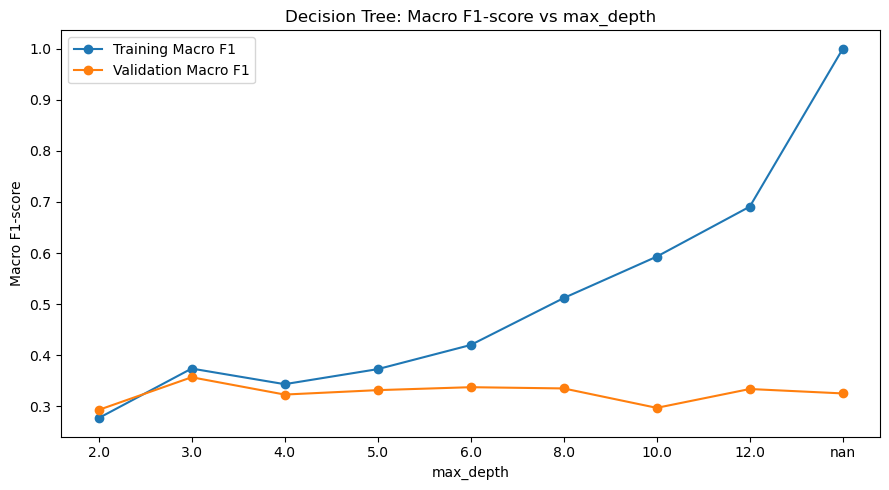

In [40]:
#prepare plotting data
dt_plot_df = dt_results_df.copy()
dt_plot_df["max_depth_label"] = dt_plot_df["max_depth"].astype(str)

plt.figure(figsize=(9, 5))
plt.plot(
    dt_plot_df["max_depth_label"],
    dt_plot_df["train_macro_f1"],
    marker="o",
    label="Training Macro F1"
)
plt.plot(
    dt_plot_df["max_depth_label"],
    dt_plot_df["val_macro_f1"],
    marker="o",
    label="Validation Macro F1"
)

plt.title("Decision Tree: Macro F1-score vs max_depth")
plt.xlabel("max_depth")
plt.ylabel("Macro F1-score")
plt.legend()
plt.tight_layout()
plt.show()

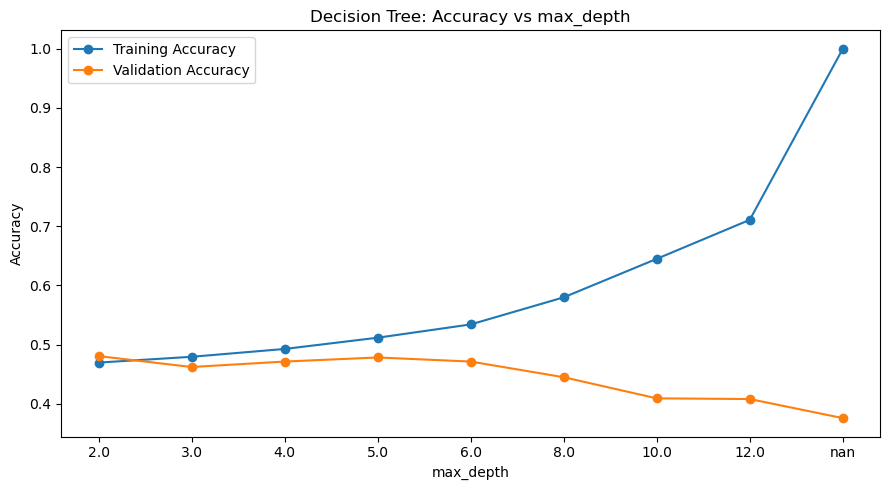

In [41]:
plt.figure(figsize=(9, 5))
plt.plot(
    dt_plot_df["max_depth_label"],
    dt_plot_df["train_accuracy"],
    marker="o",
    label="Training Accuracy"
)
plt.plot(
    dt_plot_df["max_depth_label"],
    dt_plot_df["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.title("Decision Tree: Accuracy vs max_depth")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

These curves are used to choose a tree depth that balances performance and generalisation. I do not choose the model only because it performs well on the training set. The validation score is more important because it gives a better indication of how the model may perform on unseen data.

### 7.4 Best Decision Tree evaluation
The best Decision Tree is selected using validation macro F1-score. I use macro F1-score because the target classes are not perfectly balanced, and the smaller classes should still matter during model selection.

After selecting the best tree, I inspect its classification report and confusion matrix. This gives more detail than a single score because it shows which fire intensity classes the model predicts well and which classes it struggles with.

In [42]:
#select best Decision Tree based on validation macro F1
best_dt_row = dt_results_df.sort_values(by="val_macro_f1", ascending=False).iloc[0]
best_dt_depth = best_dt_row["max_depth"]

best_dt_model = decision_tree_models[best_dt_depth]

print("Best Decision Tree max_depth:", best_dt_depth)
display(pd.DataFrame([best_dt_row]))

Best Decision Tree max_depth: 3.0


,model,train_accuracy,val_accuracy,train_macro_f1,val_macro_f1,train_weighted_f1,val_weighted_f1,max_depth
1,Decision Tree max_depth=3,0.479263,0.461982,0.373706,0.356689,0.437003,0.420562,3.0


Best Decision Tree - Validation Classification Report
              precision    recall  f1-score   support

         Low     0.0000    0.0000    0.0000       140
    Moderate     0.5056    0.5859    0.5428       384
        High     0.3933    0.5709    0.4658       268
     Extreme     0.6765    0.3026    0.4182        76

    accuracy                         0.4620       868
   macro avg     0.3939    0.3649    0.3567       868
weighted avg     0.4044    0.4620    0.4206       868



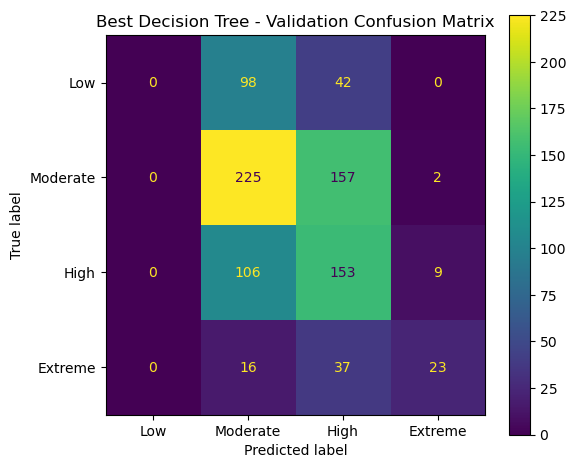

In [43]:
#predict using best Decision Tree
best_dt_train_pred = best_dt_model.predict(X_train)
best_dt_val_pred = best_dt_model.predict(X_val)

print("Best Decision Tree - Validation Classification Report")
show_classification_report(y_val, best_dt_val_pred)

plot_confusion_matrix(
    y_val,
    best_dt_val_pred,
    "Best Decision Tree - Validation Confusion Matrix"
)

The classification report and confusion matrix show how the selected Decision Tree performs across the four fire intensity classes.

If a class has low precision, recall, or F1-score, this means the model is struggling with that class. This is especially important for the Extreme class because it has fewer samples but represents the highest-risk fire events.

If any class receives no predicted samples, its precision is set to 0 in the report. This is not a coding error. It is useful evidence that the model may be biased toward the more common or easier-to-separate classes. This is one reason why I use macro F1-score and the confusion matrix rather than relying only on accuracy.

### 7.5 Decision Tree visualisation
A useful advantage of Decision Trees is that the learned structure can be visualised. This helps show which features the model uses near the top of the tree and how the model starts separating the fire intensity classes.

The full tree may be too large to read clearly, so I limit the displayed depth to 3 levels. This keeps the visualisation readable while still showing the main early splits.

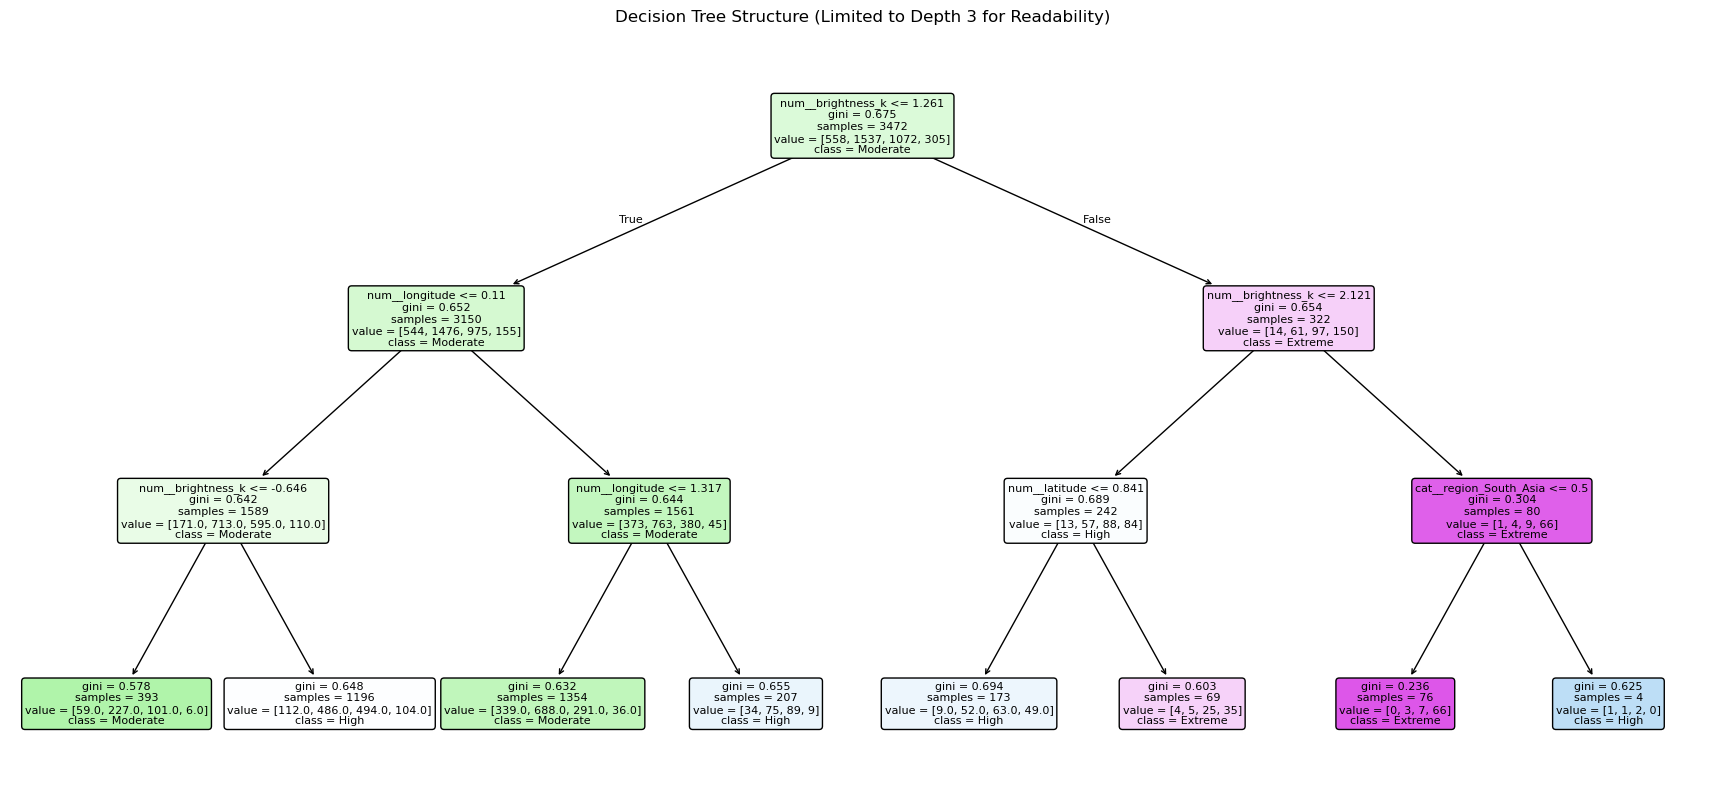

In [44]:
#get the fitted Decision Tree classifier from the pipeline
fitted_dt_classifier = best_dt_model.named_steps["model"]

#get transformed feature names after preprocessing
feature_names = best_dt_model.named_steps["preprocessor"].get_feature_names_out()

plt.figure(figsize=(22, 10))
plot_tree(
    fitted_dt_classifier,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.title("Decision Tree Structure (Limited to Depth 3 for Readability)")
plt.show()

The tree visualisation helps interpret the model by showing the features used in the early decision rules. Features near the top of the tree are especially important because they split a larger portion of the data.

This visualisation should be interpreted carefully. It shows how the Decision Tree makes decisions, but it does not prove that these features cause fire intensity. It only shows which features were useful for splitting the training data in this model.

### 7.6 Decision Tree feature importance
Feature importance shows which transformed features contributed most to the Decision Tree splits. This is useful because it gives evidence about which variables the tree relied on when separating Low, Moderate, High, and Extreme fire intensity classes.

This section is also important for analysis because it moves beyond only reporting model scores. It helps explain why the model behaves the way it does.

In [45]:
#extract feature importances from the fitted Decision Tree
dt_importances = fitted_dt_classifier.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": dt_importances
}).sort_values(by="importance", ascending=False)

#show top 20 features
feature_importance_df.head(20)

,feature,importance
4,num__brightness_k,0.690818
1,num__longitude,0.256081
0,num__latitude,0.029933
21,cat__region_South_Asia,0.023168
58,cat__country_Zambia,0.000000
56,cat__country_Venezuela,0.000000
55,cat__country_USA,0.000000
54,cat__country_Turkey,0.000000
53,cat__country_Thailand,0.000000
52,cat__country_Tanzania,0.000000


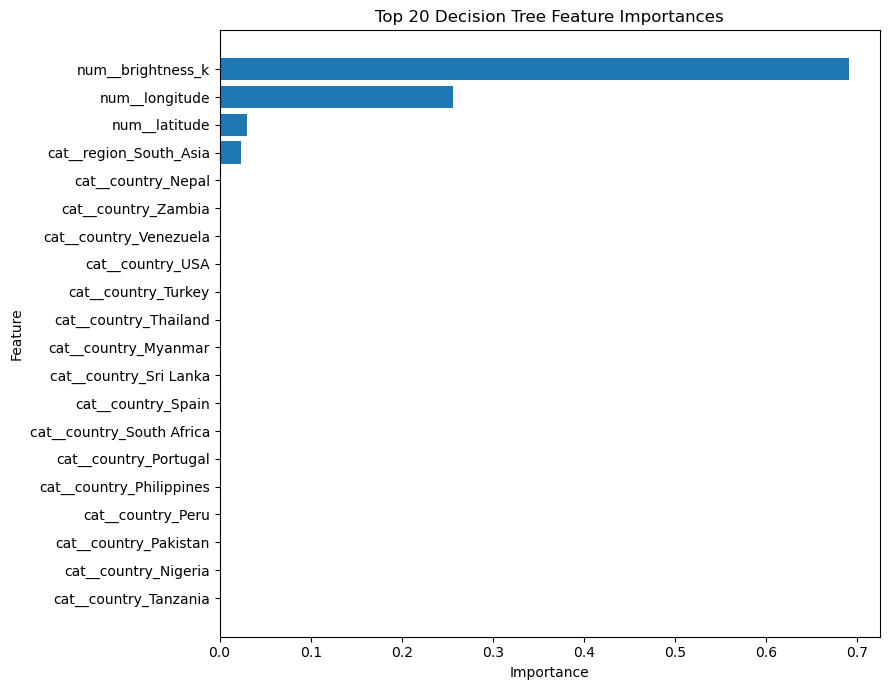

In [46]:
#plot top 20 feature importances
top_n = 20
top_features = feature_importance_df.head(top_n).sort_values(by="importance")

plt.figure(figsize=(9, 7))
plt.barh(top_features["feature"], top_features["importance"])

plt.title("Top 20 Decision Tree Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

The feature importance plot shows which features were most influential in the selected Decision Tree. Features with higher importance were used more effectively by the tree to reduce class impurity during splitting.

If satellite observation features, weather variables, or confidence-related features appear near the top, this supports the idea that wildfire intensity is linked to both environmental conditions and detection characteristics.

However, feature importance should not be over-interpreted. A feature can appear important because it works well with this specific model and split of the data. It should be used as supporting evidence, not as a standalone conclusion.

### 7.7 Decision Tree analysis
The Decision Tree experiment shows how model complexity affects performance. A very shallow tree is easier to interpret, but it may miss important patterns in the data. A deeper tree can capture more detailed relationships, but it can also overfit by learning patterns that are too specific to the training set.

The best tree is selected based on validation macro F1-score, not training performance. This is important because high training performance alone does not mean the model will generalise well. The training and validation curves help show whether increasing `max_depth` improves real validation performance or mainly improves training performance.

The Decision Tree is useful in this assignment because it provides both predictions and interpretation. The tree visualisation and feature importance plot help explain which features the model relies on. However, the model may still struggle with smaller classes, especially if the class distribution is imbalanced.

Overall, the Decision Tree provides a clear and interpretable baseline for the wildfire intensity classification task. The next models, SVM and Neural Network, will test whether more flexible decision boundaries can improve performance.

## 8. Support Vector Machine
The second model I develop is a Support Vector Machine classifier. SVM is one of the required models for this assignment, so I include it as part of the model comparison.

Compared with the Decision Tree, SVM separates classes in a different way. A Decision Tree creates a sequence of split rules, while SVM tries to find decision boundaries that separate classes in feature space. In the Week 6 course material, SVM is introduced as a method that tries to separate classes using a hyperplane, and when the data is not easily separable, the approach can be extended using softer margins and richer feature spaces.

For this wildfire dataset, SVM may be useful because fire intensity is likely influenced by several features together, such as satellite brightness, confidence level, weather conditions, region, and fire type. I compare a linear kernel and an RBF kernel because the assignment specifically asks how performance differs between these two kernels.

The preprocessing pipeline is used here to apply missing value handling, categorical encoding, and numerical scaling consistently. Scaling is especially important for SVM because the model is sensitive to the relative scale of numerical features.

### 8.1 Linear vs RBF kernel experiment
This experiment compares two SVM kernels:

- `linear`: creates a simpler linear decision boundary.
- `rbf`: creates a more flexible non-linear decision boundary.

I also test different values of `C`, which controls regularisation. A smaller `C` allows more tolerance for classification errors and usually gives a simpler model. A larger `C` tries harder to classify the training samples correctly, but this can increase the risk of overfitting.

The models are trained using the training split from `wildfire_cls_train_full.csv` and evaluated using the validation split from the same labelled dataset. The provided test dataset, `wildfire_cls_test_features.csv`, is not used here because it does not contain true `fire_intensity` labels.

In [47]:
#test SVM kernels and C values
svm_kernels = ["linear", "rbf"]
c_values = [0.1, 1, 10]

svm_results = []
svm_models = {}

for kernel in svm_kernels:
    for c in c_values:
        model_name = f"SVM kernel={kernel}, C={c}"
        
        svm_model = Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", SVC(
                kernel=kernel,
                C=c,
                random_state=RANDOM_STATE
            ))
        ])
        
        results, train_pred, val_pred = evaluate_model(
            svm_model,
            X_train,
            y_train,
            X_val,
            y_val,
            model_name
        )
        
        results["kernel"] = kernel
        results["C"] = c
        
        svm_results.append(results)
        svm_models[(kernel, c)] = svm_model

#convert results to DataFrame
svm_results_df = pd.DataFrame(svm_results)

### 8.2 SVM performance curves
The performance curves show how SVM performance changes as `C` changes for each kernel. This is useful because a single result table does not clearly show how sensitive the model is to the regularisation setting.

I compare training and validation macro F1-score because this helps show whether increasing `C` improves generalisation or mainly improves training performance.

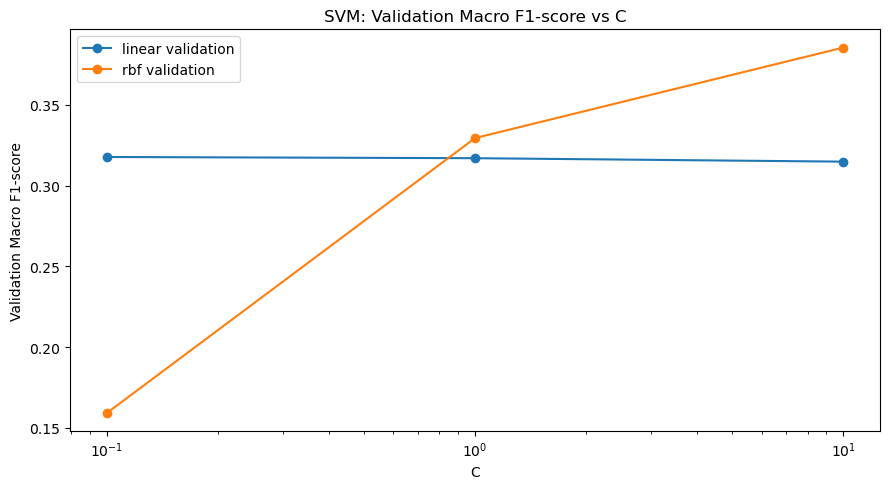

In [48]:
#plot validation macro F1 for each kernel and C value
plt.figure(figsize=(9, 5))

for kernel in svm_kernels:
    subset = svm_results_df[svm_results_df["kernel"] == kernel]
    plt.plot(
        subset["C"],
        subset["val_macro_f1"],
        marker="o",
        label=f"{kernel} validation"
    )

plt.xscale("log")
plt.title("SVM: Validation Macro F1-score vs C")
plt.xlabel("C")
plt.ylabel("Validation Macro F1-score")
plt.legend()
plt.tight_layout()
plt.show()

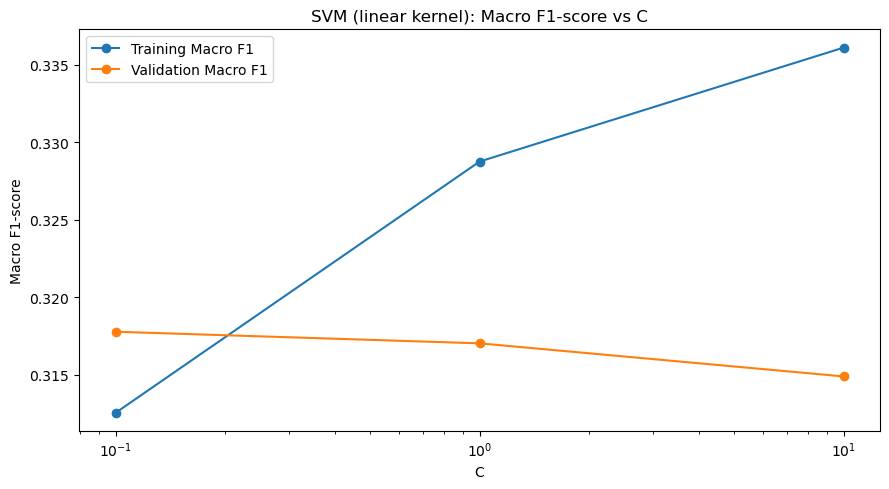

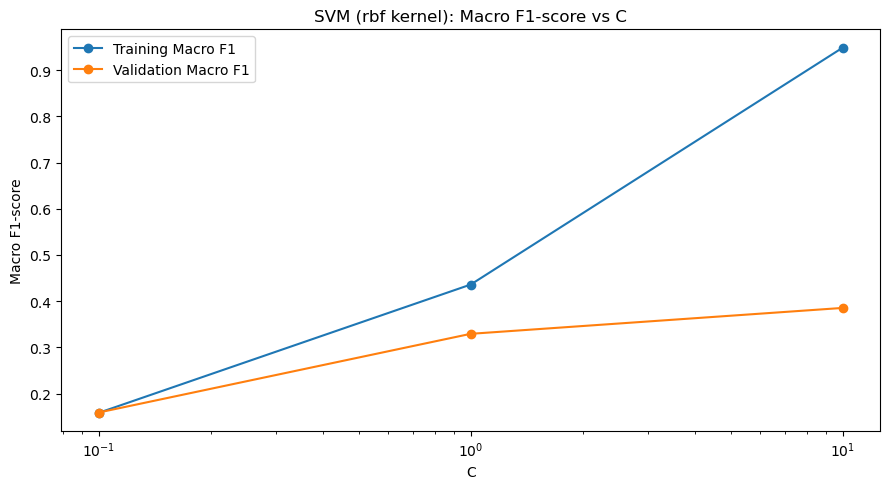

In [49]:
#plot training vs validation macro F1 for each kernel
for kernel in svm_kernels:
    subset = svm_results_df[svm_results_df["kernel"] == kernel]
    
    plt.figure(figsize=(9, 5))
    plt.plot(
        subset["C"],
        subset["train_macro_f1"],
        marker="o",
        label="Training Macro F1"
    )
    plt.plot(
        subset["C"],
        subset["val_macro_f1"],
        marker="o",
        label="Validation Macro F1"
    )
    
    plt.xscale("log")
    plt.title(f"SVM ({kernel} kernel): Macro F1-score vs C")
    plt.xlabel("C")
    plt.ylabel("Macro F1-score")
    plt.legend()
    plt.tight_layout()
    plt.show()

These plots help identify whether the SVM is underfitting or overfitting as `C` changes. If training performance increases while validation performance stays flat or decreases, then the model may be becoming too fitted to the training data. If both training and validation improve, then the higher `C` value may be helping the model learn a better decision boundary.

### 8.3 SVM hyperparameter results
The table below shows the SVM results for each kernel and `C` value. I sort the table by validation macro F1-score because macro F1-score gives equal importance to all four fire intensity classes.

This table is used to choose the best SVM setting before evaluating that selected model in more detail.

In [50]:
#display SVM hyperparameter results sorted by validation macro F1
svm_results_df.sort_values(by="val_macro_f1", ascending=False)

,model,train_accuracy,val_accuracy,train_macro_f1,val_macro_f1,train_weighted_f1,val_weighted_f1,kernel,C
5,"SVM kernel=rbf, C=10",0.948445,0.434332,0.948504,0.385530,0.948329,0.425663,rbf,10.0
4,"SVM kernel=rbf, C=1",0.572005,0.480415,0.436058,0.329504,0.506798,0.402078,rbf,1.0
0,"SVM kernel=linear, C=0.1",0.476094,0.470046,0.312534,0.317769,0.381015,0.380515,linear,0.1
1,"SVM kernel=linear, C=1",0.474942,0.452765,0.328750,0.317020,0.394149,0.374613,linear,1.0
2,"SVM kernel=linear, C=10",0.477247,0.451613,0.336104,0.314885,0.397120,0.373548,linear,10.0
3,"SVM kernel=rbf, C=0.1",0.445565,0.444700,0.158564,0.159270,0.278318,0.278926,rbf,0.1


The SVM results show that the best setting is the RBF kernel with `C = 10`. This model achieved the highest validation macro F1-score among the tested SVM settings.

The linear kernel is more stable across different `C` values, but its validation macro F1-score stays lower than the best RBF result. This suggests that a simple linear boundary does not separate the wildfire intensity classes as well as the more flexible RBF boundary.

The RBF model with `C = 0.1` performs poorly, which suggests underfitting. Increasing `C` improves the RBF model, but the training score becomes much higher than the validation score at `C = 10`, which shows that the model is becoming more complex and may be starting to overfit.

### 8.4 Best SVM model evaluation
After testing different kernels and `C` values, the best SVM model is selected using validation macro F1-score. This section evaluates the selected SVM in more detail using the validation set.

The evaluation includes:

- training and validation accuracy
- training and validation macro F1-score
- training and validation weighted F1-score
- class-level precision, recall, and F1-score
- validation confusion matrix

This gives a clearer view of how well the SVM separates the four fire intensity classes, instead of relying on one overall score only.

In [51]:
#select best SVM based on validation macro F1
best_svm_row = svm_results_df.sort_values(by="val_macro_f1", ascending=False).iloc[0]
best_svm_kernel = best_svm_row["kernel"]
best_svm_c = best_svm_row["C"]

best_svm_model = svm_models[(best_svm_kernel, best_svm_c)]

print("Best SVM kernel:", best_svm_kernel)
print("Best SVM C:", best_svm_c)
display(pd.DataFrame([best_svm_row]))

Best SVM kernel: rbf
Best SVM C: 10.0


,model,train_accuracy,val_accuracy,train_macro_f1,val_macro_f1,train_weighted_f1,val_weighted_f1,kernel,C
5,"SVM kernel=rbf, C=10",0.948445,0.434332,0.948504,0.38553,0.948329,0.425663,rbf,10.0


Best SVM - Validation Classification Report
              precision    recall  f1-score   support

         Low     0.2255    0.1643    0.1901       140
    Moderate     0.5023    0.5781    0.5375       384
        High     0.3813    0.3955    0.3883       268
     Extreme     0.5652    0.3421    0.4262        76

    accuracy                         0.4343       868
   macro avg     0.4186    0.3700    0.3855       868
weighted avg     0.4258    0.4343    0.4257       868



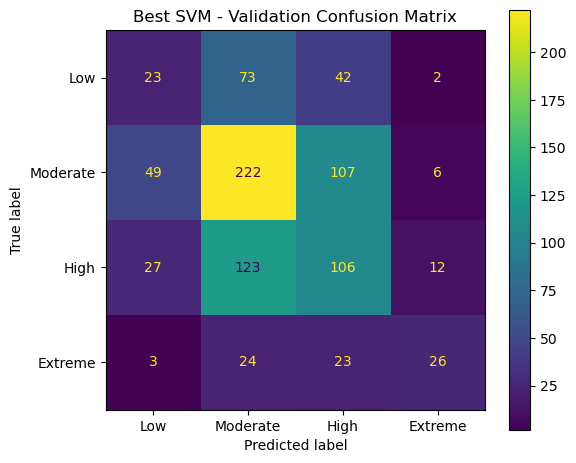

In [52]:
#evaluate the selected SVM model on the validation set
best_svm_train_pred = best_svm_model.predict(X_train)
best_svm_val_pred = best_svm_model.predict(X_val)

print("Best SVM - Validation Classification Report")
show_classification_report(y_val, best_svm_val_pred)

plot_confusion_matrix(
    y_val,
    best_svm_val_pred,
    "Best SVM - Validation Confusion Matrix"
)

The selected SVM model is the RBF kernel with `C = 10`. It achieved a validation accuracy of about 0.434 and a validation macro F1-score of about 0.386.

The classification report shows that the model performs best on the Moderate class, which is also the largest class in the dataset. The Extreme class has a higher F1-score than Low and High in this run, but it still has a small support count, so its result should be interpreted carefully.

The confusion matrix shows that many Low and High samples are predicted as Moderate. This suggests that the SVM tends to favour the middle intensity classes and has difficulty separating nearby classes. For example, many High fires are confused with Moderate fires, which is an important limitation for a wildfire intensity prediction task.

This is why macro F1-score and the confusion matrix are useful. Accuracy alone would not clearly show which classes are being confused.

### 8.5 SVM analysis
The SVM experiment compares a simpler linear decision boundary with a more flexible RBF decision boundary. In this experiment, the RBF kernel with `C = 10` achieved the strongest validation macro F1-score. This suggests that the wildfire intensity classes are not separated well by a simple linear boundary.

The `C` experiment also shows the effect of regularisation. For the RBF kernel, `C = 0.1` underfits because both training and validation performance are low. Increasing `C` to 1 improves the validation result, and `C = 10` gives the best validation macro F1-score. However, the training macro F1-score at `C = 10` is much higher than the validation macro F1-score, which suggests that the model is fitting the training data more strongly than it generalises.

Compared with the Decision Tree, SVM is less directly interpretable because it does not produce a simple tree structure. However, it is useful for testing whether a margin-based classifier with a non-linear kernel can separate the wildfire intensity classes more effectively.

Overall, the SVM results show that the RBF kernel is more suitable than the linear kernel for this dataset, but the validation performance still leaves room for improvement. The model still confuses several classes, especially Low, Moderate, and High.

## 9. Neural Network
The third model I develop is a Neural Network classifier. Neural Network is one of the required models for this assignment, so it is included alongside Decision Tree and SVM.

For this notebook, I use scikit-learn's `MLPClassifier`, which implements a Multi-Layer Perceptron. I do not use PyTorch in this assignment because the goal is to compare the required models clearly within the COSC2673 scope, rather than build a custom deep learning model from scratch.

A Neural Network may be useful for this wildfire dataset because it can learn non-linear relationships between the input features and the target classes. Fire intensity is likely influenced by a combination of satellite observations, weather conditions, location, and categorical fire information, so a model that can learn more flexible patterns may be helpful.

Compared with Decision Tree, the Neural Network is less interpretable. Compared with SVM, it has a different training process because it learns internal weights through repeated optimisation. Because of this, I pay attention not only to validation performance, but also to the training loss curves.

The assignment specifically asks how the learning rate affects model training behaviour. Therefore, this section tests several learning rates and compares their effect on validation performance and training loss.

### 9.1 Learning rate experiment
The learning rate controls how large the model's weight updates are during training. If the learning rate is too small, the model may learn slowly and may not reach a good solution within the maximum number of iterations. If the learning rate is too large, training may become unstable and the loss may not decrease smoothly.

I test four learning rates:

- `0.0001`
- `0.001`
- `0.01`
- `0.1`

The models are trained using the training split from `wildfire_cls_train_full.csv` and evaluated using the validation split from the same labelled dataset. The provided test dataset, `wildfire_cls_test_features.csv`, is not used here because it does not contain true `fire_intensity` labels.

The hidden layer structure is kept the same for all learning rates so that the experiment focuses on the effect of the learning rate.

In [53]:
#Neural Network learning rate experiment
#this experiment focuses on learning_rate_init
import warnings
from sklearn.exceptions import ConvergenceWarning

learning_rates = [0.0001, 0.001, 0.01, 0.1]

nn_results = []
nn_models = {}
nn_loss_curves = {}

for lr in learning_rates:
    model_name = f"Neural Network learning_rate={lr}"
    
    nn_model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            solver="adam",
            learning_rate_init=lr,
            max_iter=300,
            random_state=RANDOM_STATE
        ))
    ])
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=ConvergenceWarning)
        
        results, train_pred, val_pred = evaluate_model(
            nn_model,
            X_train,
            y_train,
            X_val,
            y_val,
            model_name
        )
    
    results["learning_rate"] = lr
    
    nn_results.append(results)
    nn_models[lr] = nn_model
    nn_loss_curves[lr] = nn_model.named_steps["model"].loss_curve_

#convert results to DataFrame
nn_results_df = pd.DataFrame(nn_results)

### 9.2 Neural Network hyperparameter results
The table below shows the Neural Network results for each learning rate. I sort the table by validation macro F1-score because macro F1-score gives equal importance to all four fire intensity classes.

This table helps identify which learning rate gives the best validation performance before looking more closely at the loss curves.

In [54]:
#sort results by validation macro F1
nn_results_df.sort_values(by="val_macro_f1", ascending=False)

,model,train_accuracy,val_accuracy,train_macro_f1,val_macro_f1,train_weighted_f1,val_weighted_f1,learning_rate
1,Neural Network learning_rate=0.001,0.994816,0.415899,0.994850,0.377674,0.994815,0.412831,0.0010
0,Neural Network learning_rate=0.0001,0.607431,0.442396,0.548033,0.376402,0.588785,0.415975,0.0001
2,Neural Network learning_rate=0.01,0.976382,0.406682,0.975351,0.365190,0.976391,0.404505,0.0100
3,Neural Network learning_rate=0.1,0.548099,0.457373,0.475408,0.358097,0.517244,0.421798,0.1000


### 9.3 Neural Network performance curve
This plot shows how the learning rate affects training and validation macro F1-score. Comparing both scores helps show whether a learning rate is underfitting, overfitting, or giving a more balanced result.

A useful learning rate should give reasonable validation performance without creating an extremely large gap between training and validation scores.

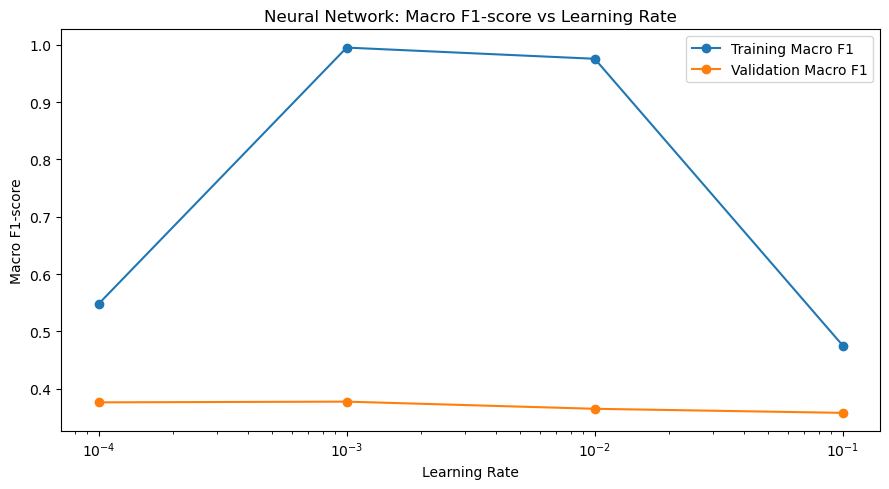

In [55]:
plt.figure(figsize=(9, 5))
plt.plot(
    nn_results_df["learning_rate"],
    nn_results_df["train_macro_f1"],
    marker="o",
    label="Training Macro F1"
)
plt.plot(
    nn_results_df["learning_rate"],
    nn_results_df["val_macro_f1"],
    marker="o",
    label="Validation Macro F1"
)

plt.xscale("log")
plt.title("Neural Network: Macro F1-score vs Learning Rate")
plt.xlabel("Learning Rate")
plt.ylabel("Macro F1-score")
plt.legend()
plt.tight_layout()
plt.show()

### 9.4 Training loss curves
The training loss curves show how the Neural Network learns across training iterations. This is required for the Neural Network part of the assignment.

A stable training process should generally show the loss decreasing over time. If the loss decreases very slowly, the learning rate may be too small. If the loss jumps around or fails to settle, the learning rate may be too large.

These curves help explain the model behaviour instead of only reporting the final validation score.

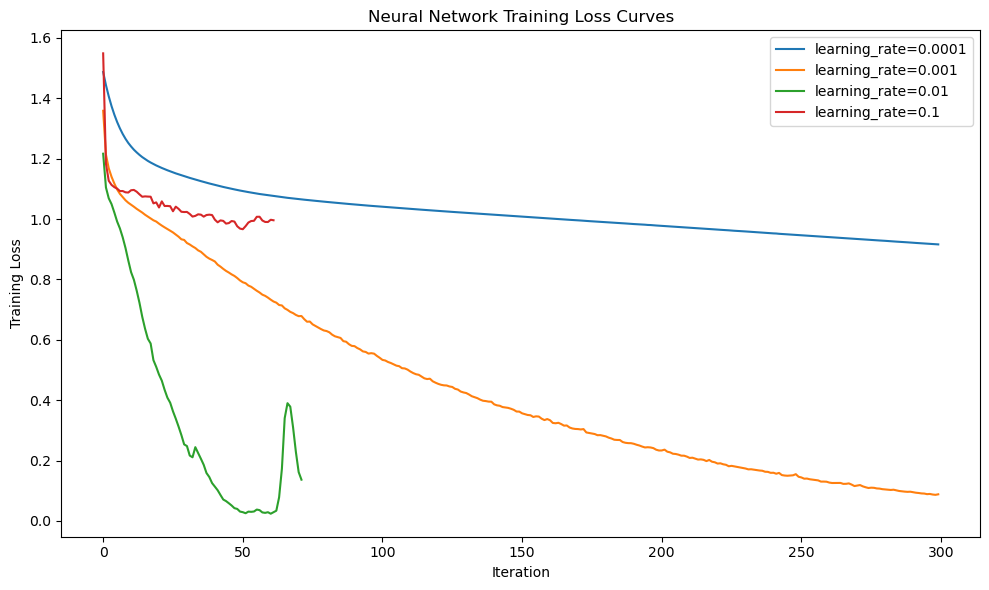

In [56]:
plt.figure(figsize=(10, 6))

for lr, loss_curve in nn_loss_curves.items():
    plt.plot(loss_curve, label=f"learning_rate={lr}")

plt.title("Neural Network Training Loss Curves")
plt.xlabel("Iteration")
plt.ylabel("Training Loss")
plt.legend()
plt.tight_layout()
plt.show()

### 9.5 Best Neural Network model evaluation
The best Neural Network is selected using validation macro F1-score. I use macro F1-score because the fire intensity classes are not perfectly balanced, and I do not want the model selection to be dominated by the larger classes.

After selecting the best Neural Network, I inspect the classification report and confusion matrix to understand how it performs across the four fire intensity classes.

In [57]:
#find best Neural Network based on validation macro F1
best_nn_row = nn_results_df.sort_values(by="val_macro_f1", ascending=False).iloc[0]
best_nn_lr = best_nn_row["learning_rate"]

best_nn_model = nn_models[best_nn_lr]

print("Best Neural Network learning rate:", best_nn_lr)
display(pd.DataFrame([best_nn_row]))

Best Neural Network learning rate: 0.001


,model,train_accuracy,val_accuracy,train_macro_f1,val_macro_f1,train_weighted_f1,val_weighted_f1,learning_rate
1,Neural Network learning_rate=0.001,0.994816,0.415899,0.99485,0.377674,0.994815,0.412831,0.001


Best Neural Network - Validation Classification Report
              precision    recall  f1-score   support

         Low     0.2481    0.2357    0.2418       140
    Moderate     0.5037    0.5365    0.5195       384
        High     0.3750    0.3358    0.3543       268
     Extreme     0.3721    0.4211    0.3951        76

    accuracy                         0.4159       868
   macro avg     0.3747    0.3823    0.3777       868
weighted avg     0.4112    0.4159    0.4128       868



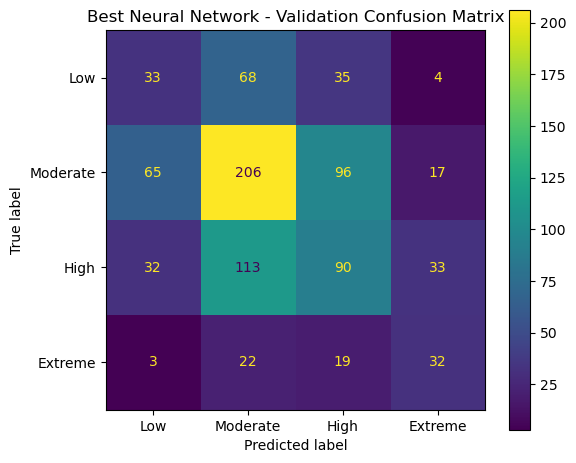

In [58]:
#aluate the selected Neural Network model on the validation set
best_nn_train_pred = best_nn_model.predict(X_train)
best_nn_val_pred = best_nn_model.predict(X_val)

print("Best Neural Network - Validation Classification Report")
show_classification_report(y_val, best_nn_val_pred)

plot_confusion_matrix(
    y_val,
    best_nn_val_pred,
    "Best Neural Network - Validation Confusion Matrix"
)

### 9.6 Neural Network analysis
The Neural Network experiment shows how sensitive the model is to the learning rate. The learning rate affects both the validation performance and the shape of the loss curve.

A very small learning rate may reduce the loss slowly and may not reach a strong solution within the maximum number of iterations. A very large learning rate may cause unstable optimisation, where the loss does not decrease smoothly. A suitable learning rate should show a reasonably smooth decrease in loss and should also achieve good validation performance.

The loss curves are useful because they show the training behaviour directly. This gives more evidence than the final scores alone. If a learning rate has a good validation score but an unstable loss curve, I would treat that result carefully.

Compared with the Decision Tree, the Neural Network is less interpretable because it does not produce simple split rules or feature importance in the same way. However, it may be able to learn more flexible relationships between the wildfire features and intensity classes.

The final model comparison will determine whether the Neural Network performs better than the Decision Tree and SVM, and whether its performance is strong enough to justify its lower interpretability.

### 9.7 Result-specific Neural Network interpretation
In this experiment, the best Neural Network learning rate was `0.001`, based on validation macro F1-score. This model achieved a validation macro F1-score of approximately 0.378 and a validation accuracy of approximately 0.416.

The learning rate results show that the Neural Network is sensitive to this hyperparameter. With `learning_rate = 0.0001`, the model has lower training performance, which suggests that the learning rate may be too small and the model may not have learned enough within the maximum number of iterations. With `learning_rate = 0.001`, the model fits the training data very strongly and gives the best validation macro F1-score, although the large gap between training and validation performance suggests overfitting.

The loss curve supports this interpretation. The curve for `learning_rate = 0.001` decreases steadily across the training iterations, which suggests that the model is learning in a stable way. In contrast, `learning_rate = 0.01` drops quickly but shows instability later in training, while `learning_rate = 0.1` appears less stable and does not achieve the best macro F1-score.

The confusion matrix shows that the Neural Network predicts the Moderate class more successfully than the other classes, but it still confuses many Low and High cases with Moderate. This suggests that the model is affected by class overlap and class imbalance. The Extreme class has some correct predictions, but the support is smaller, so its performance should be interpreted carefully.

Overall, the Neural Network is able to learn complex patterns, but it does not clearly outperform the other models based on validation macro F1-score. Its flexibility also comes with a higher risk of overfitting, so the final model selection should compare it against the Decision Tree and SVM using both performance and stability. 
Although `learning_rate = 0.1` achieved the highest validation accuracy, it was not selected as the best Neural Network because its validation macro F1-score was lower. This shows why accuracy alone is not enough for this dataset, since the classes are not perfectly balanced.

## 10. Comparison and Analysis
This section compares the three required models: Decision Tree, SVM, and Neural Network. The comparison uses the validation split from `wildfire_cls_train_full.csv`, not the provided test dataset. The test dataset is only used later for final prediction.

The models are compared using:

- validation accuracy
- validation macro F1-score
- validation weighted F1-score
- training vs validation gap
- confusion matrix behaviour
- sensitivity to hyperparameters
- interpretability and practical suitability

I focus mainly on validation macro F1-score because the fire intensity classes are not perfectly balanced. Macro F1-score gives equal importance to Low, Moderate, High, and Extreme classes, which is important for this task.

### 10.1 Collect best model results
The best version of each model is selected based on validation macro F1-score from the experiments above. This gives a consistent comparison because the same validation split and metric are used for all three models.

In [59]:
best_dt_summary = best_dt_row.copy()
best_dt_summary["model_family"] = "Decision Tree"

best_svm_summary = best_svm_row.copy()
best_svm_summary["model_family"] = "SVM"

best_nn_summary = best_nn_row.copy()
best_nn_summary["model_family"] = "Neural Network"

best_model_comparison = pd.DataFrame([
    best_dt_summary,
    best_svm_summary,
    best_nn_summary
])

comparison_cols = [
    "model_family",
    "model",
    "train_accuracy",
    "val_accuracy",
    "train_macro_f1",
    "val_macro_f1",
    "train_weighted_f1",
    "val_weighted_f1"
]

best_model_comparison = best_model_comparison[comparison_cols]

best_model_comparison["accuracy_gap"] = (
    best_model_comparison["train_accuracy"] - best_model_comparison["val_accuracy"]
)

best_model_comparison["macro_f1_gap"] = (
    best_model_comparison["train_macro_f1"] - best_model_comparison["val_macro_f1"]
)

#sort by validation macro F1-score
best_model_comparison.sort_values(by="val_macro_f1", ascending=False)

,model_family,model,train_accuracy,val_accuracy,train_macro_f1,val_macro_f1,train_weighted_f1,val_weighted_f1,accuracy_gap,macro_f1_gap
5,SVM,"SVM kernel=rbf, C=10",0.948445,0.434332,0.948504,0.385530,0.948329,0.425663,0.514113,0.562974
1,Neural Network,Neural Network learning_rate=0.001,0.994816,0.415899,0.994850,0.377674,0.994815,0.412831,0.578917,0.617176
1,Decision Tree,Decision Tree max_depth=3,0.479263,0.461982,0.373706,0.356689,0.437003,0.420562,0.017281,0.017017


The comparison table shows that the SVM with an RBF kernel and `C = 10` achieved the highest validation macro F1-score. The Neural Network with learning rate `0.001` achieved the second-highest validation macro F1-score, while the Decision Tree with `max_depth = 3` achieved the lowest validation macro F1-score among the three selected models.

However, the table also shows that the SVM and Neural Network have much larger training-validation gaps than the Decision Tree. This means that although they fit the training data more strongly, their validation performance is much lower than their training performance. This suggests possible overfitting. The Decision Tree has weaker validation macro F1-score, but it is much more stable across training and validation.

### 10.2 Model performance comparison
The following plots compare the validation accuracy, validation macro F1-score, and validation weighted F1-score of the best model from each model family.

Accuracy gives an overall view of correct predictions, but macro F1-score is more important for this dataset because the classes are not perfectly balanced. Weighted F1-score is also useful because it accounts for the number of samples in each class.

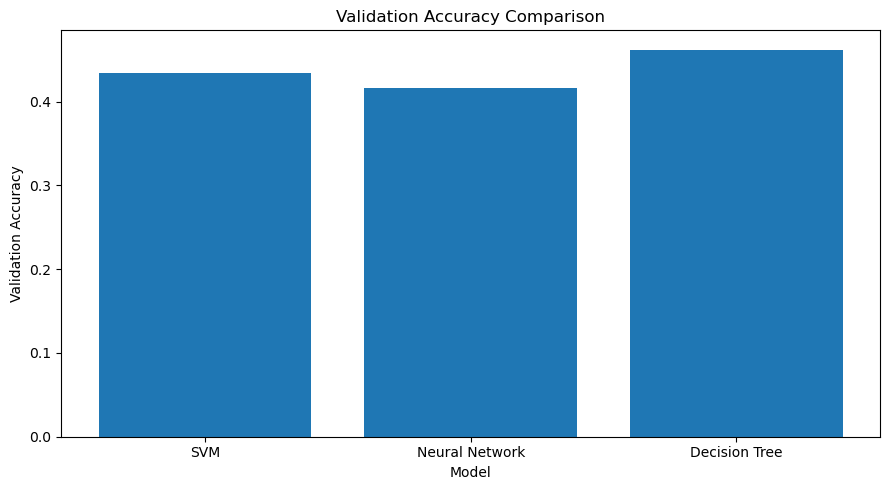

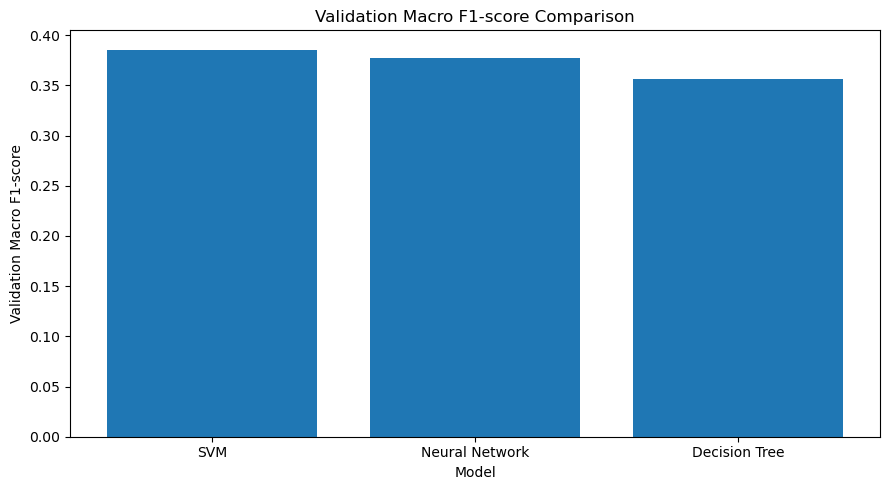

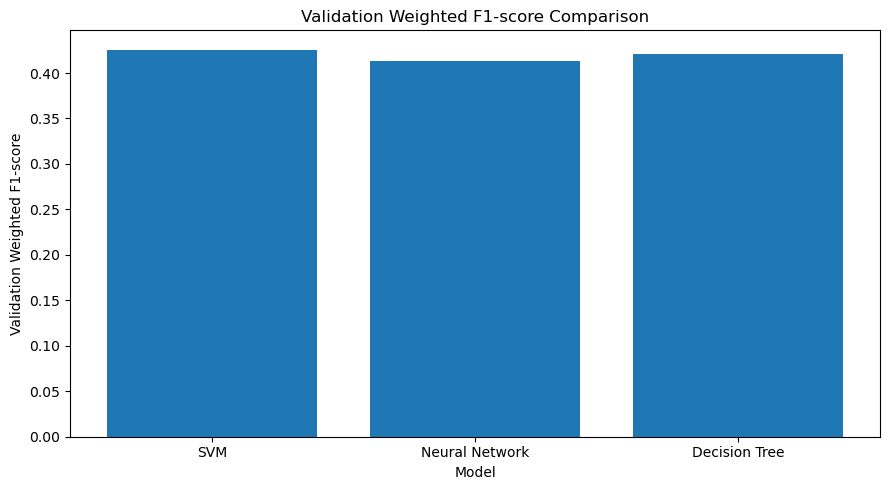

In [60]:
best_model_comparison_sorted = best_model_comparison.sort_values(
    by="val_macro_f1",
    ascending=False
)

model_labels = best_model_comparison_sorted["model_family"]

plt.figure(figsize=(9, 5))
plt.bar(model_labels, best_model_comparison_sorted["val_accuracy"])
plt.title("Validation Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Validation Accuracy")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.bar(model_labels, best_model_comparison_sorted["val_macro_f1"])
plt.title("Validation Macro F1-score Comparison")
plt.xlabel("Model")
plt.ylabel("Validation Macro F1-score")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.bar(model_labels, best_model_comparison_sorted["val_weighted_f1"])
plt.title("Validation Weighted F1-score Comparison")
plt.xlabel("Model")
plt.ylabel("Validation Weighted F1-score")
plt.tight_layout()
plt.show()

The validation accuracy plot shows that the Decision Tree has the highest validation accuracy, but it does not have the highest validation macro F1-score. This is important because accuracy can be influenced by the larger classes. The validation macro F1-score plot shows that SVM performs best overall when each class is treated equally. This supports selecting SVM as the strongest model based on the main evaluation metric. The Neural Network is close behind SVM, while the Decision Tree performs lower on macro F1-score. The weighted F1-score values are closer to accuracy because they give more influence to larger classes such as Moderate and High. This confirms why macro F1-score is a better main metric for this task.

### 10.3 Training vs validation gap
Training and validation gaps help show whether a model is likely underfitting or overfitting. A model with high training performance but much lower validation performance may be overfitting. A model with both low training and validation performance may be underfitting. A useful model should have reasonable validation performance and should not rely only on memorising the training data.

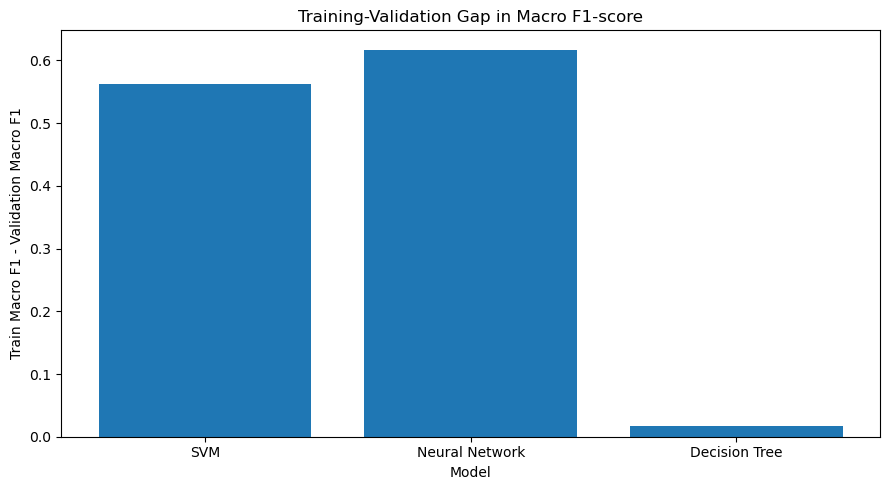

,model_family,model,train_accuracy,val_accuracy,train_macro_f1,val_macro_f1,train_weighted_f1,val_weighted_f1,accuracy_gap,macro_f1_gap
5,SVM,"SVM kernel=rbf, C=10",0.948445,0.434332,0.948504,0.385530,0.948329,0.425663,0.514113,0.562974
1,Neural Network,Neural Network learning_rate=0.001,0.994816,0.415899,0.994850,0.377674,0.994815,0.412831,0.578917,0.617176
1,Decision Tree,Decision Tree max_depth=3,0.479263,0.461982,0.373706,0.356689,0.437003,0.420562,0.017281,0.017017


In [61]:
plt.figure(figsize=(9, 5))
plt.bar(best_model_comparison_sorted["model_family"], best_model_comparison_sorted["macro_f1_gap"])
plt.title("Training-Validation Gap in Macro F1-score")
plt.xlabel("Model")
plt.ylabel("Train Macro F1 - Validation Macro F1")
plt.tight_layout()
plt.show()

best_model_comparison_sorted

The training-validation gap shows a major difference between the models. The Decision Tree has the smallest macro F1 gap, which means its training and validation performance are close. This suggests that the selected Decision Tree is stable and not strongly overfitting. The SVM and Neural Network have much larger macro F1 gaps. Both models fit the training data very strongly, but their validation macro F1-scores are much lower. This suggests that these models may be overfitting to the training data. Even though the SVM has the highest validation macro F1-score, this gap needs to be considered when choosing the final model. A high validation score is useful, but the model should also be judged by stability and generalisation behaviour.

### 10.4 Confusion matrix comparison
The confusion matrices show how each model performs across the four fire intensity classes. This is important because two models may have similar overall scores but make different types of mistakes.

For this wildfire task, confusing Extreme fires with lower intensity classes would be more concerning than minor confusion between nearby classes, because Extreme fires represent the highest-risk category.

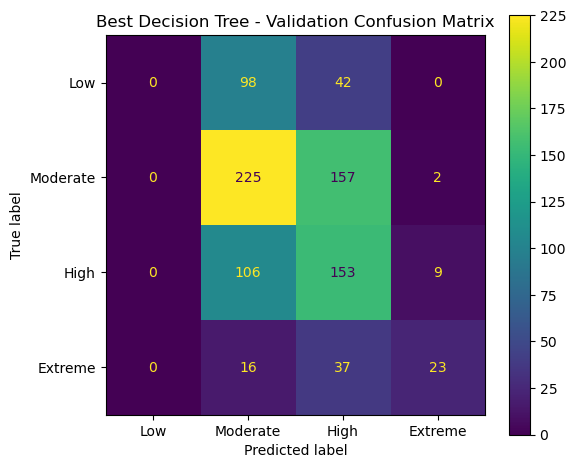

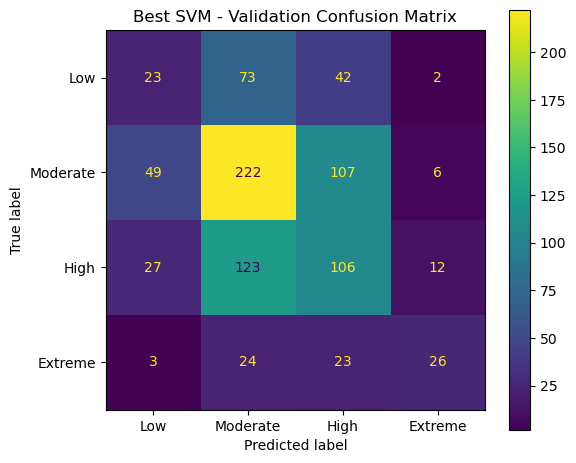

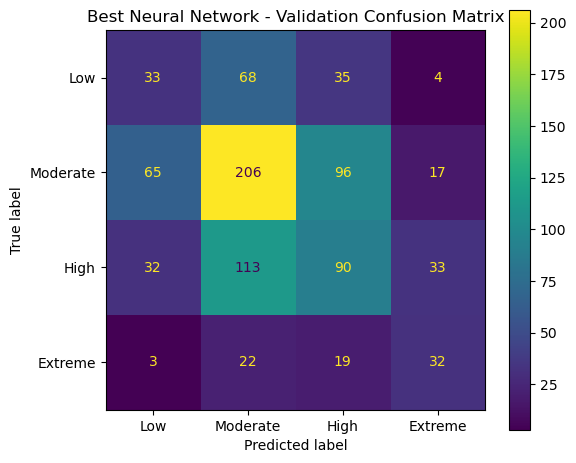

In [62]:
plot_confusion_matrix(
    y_val,
    best_dt_val_pred,
    "Best Decision Tree - Validation Confusion Matrix"
)

plot_confusion_matrix(
    y_val,
    best_svm_val_pred,
    "Best SVM - Validation Confusion Matrix"
)

plot_confusion_matrix(
    y_val,
    best_nn_val_pred,
    "Best Neural Network - Validation Confusion Matrix"
)

The confusion matrices show that all models struggle to clearly separate every fire intensity class. A common pattern is confusion between Low, Moderate, and High classes. This suggests that the boundary between these intensity levels is not simple. The SVM and Neural Network both make use of more flexible decision boundaries, but they still confuse many samples between nearby classes. The Decision Tree is more stable, but its class-level performance is weaker overall. This confirms that the task is not simply solved by using a more complex model. The models need to balance flexibility with generalisation.

### 10.5 Class-level F1-score comparison
Overall metrics are useful, but they do not show how well each individual fire intensity class is predicted. To compare the models more carefully, I calculate F1-score for each class.

This helps identify whether a model performs well only on the larger classes, or whether it also handles smaller classes such as Extreme.

In [63]:
class_f1_comparison = pd.DataFrame({
    "Class": class_names,
    "Decision Tree": f1_score(y_val, best_dt_val_pred, average=None, labels=[0, 1, 2, 3], zero_division=0),
    "SVM": f1_score(y_val, best_svm_val_pred, average=None, labels=[0, 1, 2, 3], zero_division=0),
    "Neural Network": f1_score(y_val, best_nn_val_pred, average=None, labels=[0, 1, 2, 3], zero_division=0)
})

class_f1_comparison

,Class,Decision Tree,SVM,Neural Network
0,Low,0.000000,0.190083,0.241758
1,Moderate,0.542823,0.537530,0.519546
2,High,0.465753,0.388278,0.354331
3,Extreme,0.418182,0.426230,0.395062


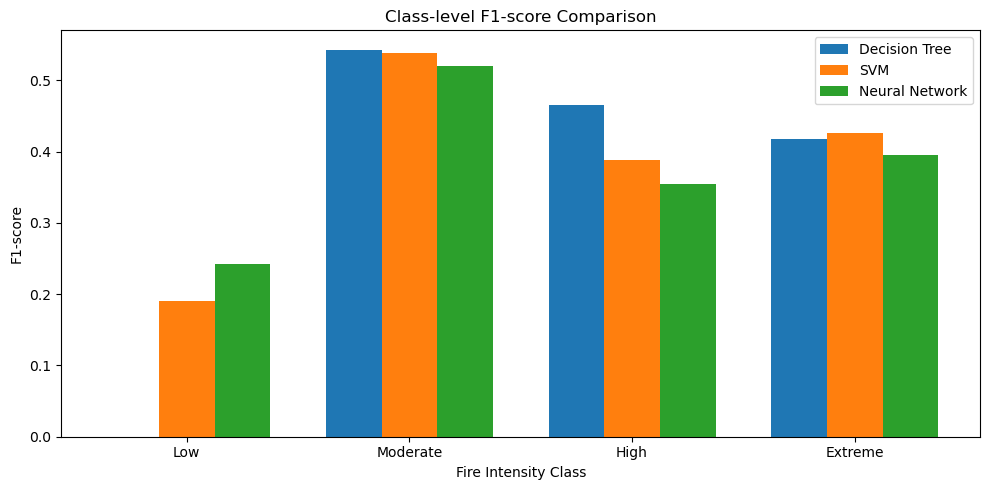

In [64]:
x = np.arange(len(class_names))
width = 0.25

plt.figure(figsize=(10, 5))
plt.bar(x - width, class_f1_comparison["Decision Tree"], width, label="Decision Tree")
plt.bar(x, class_f1_comparison["SVM"], width, label="SVM")
plt.bar(x + width, class_f1_comparison["Neural Network"], width, label="Neural Network")

plt.xticks(x, class_names)
plt.title("Class-level F1-score Comparison")
plt.xlabel("Fire Intensity Class")
plt.ylabel("F1-score")
plt.legend()
plt.tight_layout()
plt.show()

The class-level F1-score comparison shows whether the models perform evenly across all fire intensity classes or mainly perform well on the more common classes.

This is important because the dataset is not perfectly balanced. A model that performs well on Moderate but poorly on Low or Extreme may still achieve reasonable overall accuracy, but it would be less reliable for real wildfire intensity classification.

Based on the earlier classification reports and confusion matrices, the models generally perform better on the larger or more central classes and struggle with clear separation between neighbouring intensity levels.

### 10.6 Model behaviour comparison
The reason for their difference lies in the type of decision boundary the models learn.

The Decision Tree is the easiest model to interpret since it includes features' importance and uses split rules as the output. Also, it has the lowest gap between train and validation metrics, indicating its stability. Nevertheless, its validation macro F1-score is lower compared to the other two classifiers, making it less capable of treating all classes evenly.

SVM with the RBF kernel is more flexible than the linear classifier and achieved the highest validation macro F1-score among all. It suggests that there is no linear boundary between the intensity of wildfires. At the same time, the RBF classifier is characterized by the largest difference between training and validation metrics, indicating its potential for overfitting.

Finally, Neural Networks can learn complicated non-linear relations; at the same time, it has poor interpretability and sensitivity to hyperparameters. The experiment with different learning rates indicated the variability of neural networks' performance and the presence of an unstable training process. The validation performance of the best neural network result is very similar to that of SVM.

It means that the increase in the complexity of algorithms does not always contribute to higher validation macro F1-score. On the contrary, SVM and neural network classifiers have better scores on the validation metric but are potentially more susceptible to overfitting.
.

### 10.7 Final comparison summary
Based on the validation results, the final model should not be selected using accuracy alone. The comparison needs to consider:

- validation macro F1-score
- validation accuracy
- class-level F1-scores
- confusion matrix behaviour
- training-validation gap
- model stability
- interpretability
- suitability for wildfire intensity prediction

The final model will be selected in the next section after considering both quantitative performance and practical model behaviour.

In [65]:
best_model_comparison_sorted

,model_family,model,train_accuracy,val_accuracy,train_macro_f1,val_macro_f1,train_weighted_f1,val_weighted_f1,accuracy_gap,macro_f1_gap
5,SVM,"SVM kernel=rbf, C=10",0.948445,0.434332,0.948504,0.385530,0.948329,0.425663,0.514113,0.562974
1,Neural Network,Neural Network learning_rate=0.001,0.994816,0.415899,0.994850,0.377674,0.994815,0.412831,0.578917,0.617176
1,Decision Tree,Decision Tree max_depth=3,0.479263,0.461982,0.373706,0.356689,0.437003,0.420562,0.017281,0.017017


### 10.8 Result-specific comparison interpretation
According to the validation comparison, the optimal algorithm with respect to the validation macro F1-score is the SVM with the RBF kernel and `C = 10`, with a validation macro F1-score of 0.386 and a validation accuracy of 0.434.

Neural Networks yielded a very similar value of validation macro F1-score, i.e., 0.378; however, it was characterised by a noticeably larger discrepancy between training and validation results. The obtained results indicate that Neural Networks fitted the training dataset very well but did not yield sufficiently high performance on the validation set. At the same time, SVMs also produced large discrepancies between training and validation performances, especially with respect to macro F1-score, indicating overfitting of the flexible RBF boundary.

The Decision Trees obtained the worst validation macro F1-score among the algorithms under study, i.e., 0.357; however, they yielded the smallest training-validation discrepancies. Therefore, this method can be considered the most stable of the three algorithms presented above, despite yielding weaker results in terms of the validation metrics. Also, Decision Trees can be regarded as the most explainable algorithm because they provide information about the tree structure and relative importance of different features.

In summary, it should be noted that more complex methods do not guarantee the achievement of better generalisation. In particular, both SVMs and Neural Networks obtained higher values of validation macro F1-score than the Decision Tree; at the same time, their training and validation discrepancies were much higher. Decision Trees are more stable and understandable; however, they yield lower results with respect to the chosen metrics.

To select the final model, all of these aspects, including class-based performance, the risk of overfitting, and interpretability will be taken into consideration.

## 11. Train Final Model on Full Training Dataset
Based on the validation comparison, the final selected model is the SVM with an RBF kernel and `C = 10`. This model achieved the highest validation macro F1-score among the three tested model families.

Before generating predictions on the provided test dataset, I retrain the selected model using the full labelled training dataset from `wildfire_cls_train_full.csv`. This allows the final model to learn from all available labelled examples, rather than only the 80% training split used during validation.

The provided test dataset, `wildfire_cls_test_features.csv`, is still not used for model selection or evaluation because it does not contain true `fire_intensity` labels. It is only used for final prediction generation.

In [66]:
#the final selected model based on validation macro F1-score
final_model_name = "SVM with RBF kernel and C=10"

final_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SVC(
        kernel="rbf",
        C=10,
        gamma="scale",
        random_state=RANDOM_STATE,
        cache_size=1000
    ))
])

print("Final selected model:", final_model_name)

Final selected model: SVM with RBF kernel and C=10


In [67]:
# Train the final model on the full labelled training dataset
final_model.fit(X_processed, y)

print("Final model trained on the full labelled training dataset.")
print("Training data used:", X_processed.shape)
print("Target data used:", y.shape)

Final model trained on the full labelled training dataset.
Training data used: (4340, 21)
Target data used: (4340,)


The final model is trained using all labelled records from `wildfire_cls_train_full.csv`. This is done only after model comparison and selection have already been completed using the validation split. This approach keeps model selection fair while still allowing the final model to use the maximum amount of labelled data before predicting the unlabelled test set.

## 12. Prediction using chosen model
This section uses the final trained model to predict `fire_intensity` for the provided test dataset, `wildfire_cls_test_features.csv`.

The assignment requires the prediction file to contain a single column named `fire_intensity`. The predictions must stay in the same order as the rows in the test dataset.

In [68]:
test_predictions = final_model.predict(X_test_processed)

print("Predictions generated successfully.")
print("Number of predictions:", len(test_predictions))
print("Number of test rows:", X_test_processed.shape[0])
print("Unique predicted classes:", np.unique(test_predictions))

Predictions generated successfully.
Number of predictions: 1085
Number of test rows: 1085
Unique predicted classes: [0 1 2 3]


In [69]:
prediction_df = pd.DataFrame({
    "fire_intensity": test_predictions
})

#zave predictions to CSV
prediction_file = "s4085541_predictions.csv"
prediction_df.to_csv(prediction_file, index=False)

print("Prediction file saved:", prediction_file)
prediction_df.head()

Prediction file saved: s4085541_predictions.csv


,fire_intensity
0,2
1,3
2,0
3,1
4,2


In [70]:
#reload the saved prediction file to verify its format
check_predictions = pd.read_csv(prediction_file)

print("Prediction file shape:", check_predictions.shape)
print("Prediction file columns:", list(check_predictions.columns))
print("Number of missing predictions:", check_predictions["fire_intensity"].isnull().sum())
print("Unique prediction values:", sorted(check_predictions["fire_intensity"].unique()))

# Required checks
correct_row_count = check_predictions.shape[0] == X_test_processed.shape[0]
correct_column_name = list(check_predictions.columns) == ["fire_intensity"]
correct_number_columns = check_predictions.shape[1] == 1
valid_prediction_values = set(check_predictions["fire_intensity"].unique()).issubset({0, 1, 2, 3})

print("\nFormat checks:")
print("Correct row count:", correct_row_count)
print("Correct column name:", correct_column_name)
print("Only one column:", correct_number_columns)
print("Only valid class labels 0-3:", valid_prediction_values)

Prediction file shape: (1085, 1)
Prediction file columns: ['fire_intensity']
Number of missing predictions: 0
Unique prediction values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

Format checks:
Correct row count: True
Correct column name: True
Only one column: True
Only valid class labels 0-3: True


## 13. Rationale for the Approach
The general structure of my approach corresponds to the machine learning process flow as needed for the assignment: task definition, data inspection, exploratory data analysis, preprocessing, modelling, hyperparameters testing, comparing models, selecting final model, and generating predictions for test dataset.

The task was considered as a multi-class classification supervised learning task because there is a labelled training dataset, and the target variable fire_intensity contains four classes: Low, Moderate, High, and Extreme.

For exploratory data analysis, I analyzed target distribution, features' distributions, relations between features and targets, and correlation between numerical features. It was especially important because of a great diversity of features: numerical, categorical, date and time columns, weather and satellite-related features, and location-based features.

In terms of preprocessing, I dealt with missing values, categorical features encoding, normalization of numerical features, transformation of date and time columns. Median imputation was applied for dealing with missing numerical features because it is simple and easy to reproduce, and it is also less dependent on extreme outliers compared to mean imputation. One-hot encoding was used for categorical features since they do not have any natural numeric ordering. Normalization of numerical columns was performed since it is required for SVM and NN algorithms.

Labelled training dataset (`wildfire_cls_train_full.csv`) was split into train and validate datasets with an 80/20 ratio. Validation dataset was used for hyperparameters testing and model comparing. Provided test dataset (`wildfire_cls_test_features.csv`) was not used for selecting models because it contains no actual labels.

Three required models were implemented and compared:

- Decision Tree
- SVM
- Neural Network

For decision tree, I varied max_depth parameter to understand influence of the model complexity on the validation results. Tree visualization and plot with feature importance were attached because one of the benefits of decision trees is that they are easy to understand.

For SVM, linear and RBF kernel was used, and C value was tested to see influence of boundary complexity and regularization on the validation results.

Learning rate was varied for neural networks, and training and validation loss curves were drawn to understand learning behavior and its dependence on learning rate.


## 14. Final evaluation
The chosen model is SVM with an RBF kernel and `C = 10`. It was picked since it showed the highest validation macro F1-score out of all the examined model families.

As noted before, the macro F1-score was picked as the selection metric since the distribution of the data set was unbalanced. In our case, it was vital to consider all four classes equally, since they represented different levels of fire intensity; hence, their significance was the same in wildfire monitoring.

SVM showed the best performance when compared with both Decision Tree and Neural Network, but, again, there was quite a significant training-validation gap, pointing to the overfitting of the RBF SVM model. Still, SVM showed itself as the most accurate model despite some issues with flexibility.

While the Decision Tree model was much less flexible than the former one due to having no training-validation gap, it demonstrated lower results in terms of validation macro F1-score. Similarly, the Neural Network performed quite similarly to SVM, but showed even higher overfitting. Moreover, it was highly sensitive to the changes in the learning rate hyperparameter.

In conclusion, it should be stated that, generally speaking, increased flexibility does not necessarily mean higher generalisability. Thus, both SVM and Neural Network models turned out to be more flexible but, at the same time, showed higher overfitting. SVM model was finally chosen based on its validation macro F1-score that was evaluated as the metric.

### 14.1 Limitations
There are several limitations to this workflow of modelling.

Firstly, the validation performance is moderate rather than excellent. This indicates that the classes of the target variable may be not separable given the set of features we use. This was confirmed by the confusion matrices where we observed that models usually classify neighbouring classes like Low, Moderate, and High.

Secondly, there is an issue of an imbalance problem between the target classes. The number of samples in the Extreme class is smaller compared to those in the Moderate and High classes.

Thirdly, the final SVM classifier shows signs of overfitting since the training macro F1-score is substantially larger compared to the validation macro F1-score. Although the classifier reached the maximum validation macro F1-score, the large discrepancy implies imperfect generalization of the model.

Fourthly, our dataset refers to particular regions and countries. The assignment says that the model generalization across other regions and countries than those covered by the data set cannot be taken into consideration. Thus, the proposed model should only be applied within the dataset scope.

Finally, this model should not be used as a standalone emergency decision-making tool. It can support analysis, but wildfire response decisions should involve expert judgement, real-time information, and emergency management procedures.


### 14.2 Ethical considerations and professional responsibilities
Considering the nature of the current task and its relevance to fire intensity, ethical and professional issues cannot be overlooked.

Inaccurate estimations of fire intensity may have consequences on emergency preparedness measures such as inadequate resource mobilization and delays in issuing warnings. Overestimation, on the other hand, might result in deploying personnel in areas where no fires are occurring.

Therefore, the model predictions are supposed to be considered as decision-support material and not decisions per se since the model itself has some weaknesses and its validation results demonstrate its confusion between the fire intensity classes. In a practical scenario, the predictions would need to be cross-checked against other sources such as satellite images, weather reports, local observations, and expert assessment.

It is also essential to convey any uncertainty surrounding the predictions in an honest manner. For instance, if the model performed poorly on particular classes or had overfitting issues, such information must be communicated and not withheld. This is even more crucial when dealing with dangerous classes such as the Extreme category.

Finally, it must be noted that the dataset should not be used beyond the scope of the assignment, as indicated in the assignment description.


### 14.3 Conclusion
Three machine learning models were developed and compared in this project in terms of their performance in predicting wildfire intensity: Decision Tree, SVM and Neural Network.

The analysis process comprised of data inspection, exploratory data analysis, data preprocessing, train-validation split, modeling, hyperparameters tuning, comparing models, selecting the best one and producing predictions on test data.

The final chosen model turned out to be SVM with a radial basis function kernel and parameter `C = 10`. This model performed best in terms of validation macro F1 score, indicating that the non-linear decision boundary worked better than the linear one or the chosen Decision Tree.

Nevertheless, it needs to be emphasized that the final model can be considered imperfect, as indicated by validation results and confusion matrices where multiple fire intensity classes remain confused. The overfitting tendencies in the selected SVM confirm this assumption and imply interpreting the final model as classification only.

The final prediction file (`s4085541_predictions.csv`) was produced based on the selected SVM.
